In [ ]:
import pandas as pd
# import scienceplots
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from scipy.stats import t
import numpy as np
import math
import time
import os
from IPython.display import clear_output, display
import ipywidgets as widgets
# widgets.IntSlider()
# import torch

df_s0 = pd.read_csv("results/seq_registration_s0.csv")
df_s100 = pd.read_csv("results/seq_registration_s100.csv")
df_s100.head()

,leaf_uid,registration_method,leaf_scale,pre_rotated,markers,warp_consistency,filtering_strategy,smoothing,fixed_image,moving_image,MSE,MAPE,NCC,MI,MI_Skimage,SSIM,IoU,Hausdorff
0,ESWW0090057_12,LoFTR + TPS Individual,roi,True,False,True,confidence,100,0,1,0.006900,57.700603,0.068925,1.025010,1.146772,0.544151,0.968838,10.049875
1,ESWW0090057_12,LoFTR + TPS Individual,roi,True,False,True,confidence,100,0,2,0.018872,102.966454,0.056326,1.018133,1.124817,0.512157,0.961272,12.165525
2,ESWW0090057_12,LoFTR + TPS Individual,roi,True,False,True,confidence,100,0,3,0.009812,68.212898,0.043351,1.017680,1.121013,0.506078,0.965055,15.023640
3,ESWW0090057_12,LoFTR + TPS Individual,roi,True,False,True,confidence,100,0,4,0.006968,59.911716,0.068278,1.024690,1.131895,0.510625,0.972509,12.000000
4,ESWW0090057_12,LoFTR + TPS Individual,roi,True,False,True,confidence,100,0,5,0.006070,53.125526,0.034311,1.018000,1.130688,0.511740,0.968976,10.160998


In [31]:
n_uids_s0 = df_s0['leaf_uid'].nunique()
n_uids_s100 = df_s100['leaf_uid'].nunique()
# n_uids = df_full['leaf_uid'].nunique()
print(f"Number of leaves evaluated for smoothness 0:\t{n_uids_s0} (of which {df_s0[df_s0['leaf_uid'].isin(test_set)]['leaf_uid'].nunique()} in test set)")
print(f"Number of leaves evaluated for smoothness 100:\t{n_uids_s100} (of which {df_s100[df_s100['leaf_uid'].isin(test_set)]['leaf_uid'].nunique()} in test set)")

Number of leaves evaluated for smoothness 0:	100 (of which 100 in test set)
Number of leaves evaluated for smoothness 100:	110 (of which 100 in test set)


## Combining Dataframes

In [33]:
df_full = pd.concat([df_s0, df_s100[df_s100['leaf_uid'].isin(test_set)]], ignore_index=True)
df_full.sample(5)

,leaf_uid,registration_method,leaf_scale,pre_rotated,markers,warp_consistency,filtering_strategy,smoothing,fixed_image,moving_image,MSE,MAPE,NCC,MI,MI_Skimage,SSIM,IoU,Hausdorff
8026,ESWW0090217_7,LoFTR + TPS Individual,roi,True,False,True,confidence,100.0,0,7,0.009887,61.940945,0.084659,1.042572,1.095164,0.424050,0.965437,12.000000
7735,ESWW0090145_2,LoFTR + TPS Individual,roi,True,False,True,confidence,100.0,0,1,0.021922,198.789459,0.055413,1.041802,1.126452,0.437958,0.958995,26.000000
7046,ESWW0090094_4,LoFTR + TPS Semi-Sequential,roi,True,False,True,confidence,100.0,0,3,0.007916,59.630329,0.009064,1.009451,1.065736,0.404016,0.954055,24.000000
5894,ESWW0070132_9,LoFTR + TPS Sequential,roi,True,False,True,confidence,100.0,0,9,0.014086,65.394302,0.010971,1.007665,1.054193,0.366331,0.946835,38.327538
7239,ESWW0090132_12,LoFTR + TPS Individual,roi,True,False,True,confidence,100.0,0,9,0.091396,302.373505,-0.002135,1.000565,1.009207,0.226992,0.553915,698.295471


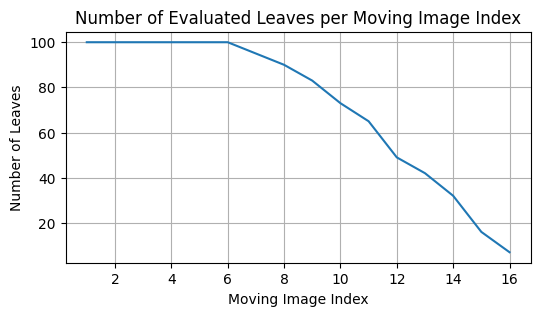

In [34]:
# method = 'LoFTR + TPS Individual'
# method = 'Baseline'
method = 'Piecewise Affine'
moving_img_ind_count = df_full[df_full['registration_method'] == method]['moving_image'].value_counts()
plt.style.use(['default'])
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.size": 10
# })
plt.figure(figsize=(6, 3))
plt.plot(moving_img_ind_count.index, moving_img_ind_count.values)
plt.grid(True)
plt.title("Number of Evaluated Leaves per Moving Image Index")
plt.xlabel("Moving Image Index")
plt.ylabel("Number of Leaves")
plt.show()

## Counting Valid Registrations per UID

In [9]:
def n_valid_registrations(df, method: str = "Piecewise Affine", smoothing=100):
    if method=="Piecewise Affine" or method == "Baseline":
        df = df[df["registration_method"] == method]
    else:
        df = df[(df["registration_method"] == method) & (df["smoothing"] == smoothing)]
    return df.groupby('leaf_uid')['MSE'].count().reset_index(name=f'Successful {method} Registrations')

In [10]:
pw_counts = n_valid_registrations(df_full, method="Piecewise Affine")
individ_counts = n_valid_registrations(df_full, method="LoFTR + TPS Individual")
seq_counts = n_valid_registrations(df_full, method="LoFTR + TPS Sequential")
semi_seq_counts = n_valid_registrations(df_full, method="LoFTR + TPS Semi-Sequential")
baseline_counts = n_valid_registrations(df_full, method="Baseline")

reg_counts = pw_counts.merge(individ_counts, on='leaf_uid', how='outer') \
    .merge(seq_counts, on='leaf_uid', how='outer') \
    .merge(semi_seq_counts, on='leaf_uid', how='outer') \
    .merge(baseline_counts, on='leaf_uid', how='outer')
reg_counts.head()

,leaf_uid,Successful Piecewise Affine Registrations,Successful LoFTR + TPS Individual Registrations,Successful LoFTR + TPS Sequential Registrations,Successful LoFTR + TPS Semi-Sequential Registrations,Successful Baseline Registrations
0,ESWW0070040_10,15,15,15,15,15.0
1,ESWW0070054_17,16,16,16,16,NaN
2,ESWW0070054_6,15,15,15,15,15.0
3,ESWW0070057_1,14,14,14,14,14.0
4,ESWW0070057_4,13,13,13,13,NaN


In [11]:
reg_counts.describe()

,Successful Piecewise Affine Registrations,Successful LoFTR + TPS Individual Registrations,Successful LoFTR + TPS Sequential Registrations,Successful LoFTR + TPS Semi-Sequential Registrations,Successful Baseline Registrations
count,100.000000,100.000000,100.000000,100.000000,58.000000
mean,10.800000,10.670000,10.840000,10.880000,10.775862
std,2.792486,2.885194,2.838124,2.825855,2.753263
min,6.000000,2.000000,6.000000,6.000000,6.000000
25%,9.000000,9.000000,9.000000,9.000000,9.000000
50%,10.000000,10.000000,10.000000,10.000000,10.000000
75%,13.000000,13.000000,13.250000,13.250000,13.000000
max,16.000000,16.000000,16.000000,16.000000,16.000000


In [ ]:
cols_to_compare = ['Successful LoFTR + TPS Individual Registrations',
       'Successful LoFTR + TPS Sequential Registrations',
       'Successful LoFTR + TPS Semi-Sequential Registrations',
       'Successful Baseline Registrations']

# Count differences vs ref column
diff_counts = (reg_counts[cols_to_compare] != reg_counts["Successful Piecewise Affine Registrations"].values.reshape(-1, 1)).sum()

print(diff_counts)

Successful LoFTR + TPS Individual Registrations          5
Successful LoFTR + TPS Sequential Registrations          2
Successful LoFTR + TPS Semi-Sequential Registrations     1
Successful Baseline Registrations                       42
dtype: int64

In [105]:
cols_to_compare = ['Successful LoFTR + TPS Individual Registrations',
       'Successful LoFTR + TPS Sequential Registrations',
       'Successful LoFTR + TPS Semi-Sequential Registrations']

reg_counts["num_different"] = (
    reg_counts[cols_to_compare] != reg_counts["Successful Piecewise Affine Registrations"].values.reshape(-1, 1)
).sum(axis=1)

reg_counts[reg_counts.num_different > 0]

,leaf_uid,Successful Piecewise Affine Registrations,Successful LoFTR + TPS Individual Registrations,Successful LoFTR + TPS Sequential Registrations,Successful LoFTR + TPS Semi-Sequential Registrations,Successful Baseline Registrations,num_different
11,ESWW0070072_9,16,10,16,16,16.0,1
25,ESWW0070165_5,14,2,14,14,NaN,1
35,ESWW0070228_6,15,13,15,15,NaN,1
44,ESWW0090026_5,12,12,8,12,12.0,1
64,ESWW0090114_6,8,7,8,8,8.0,1
88,ESWW0090203_3,8,16,16,16,NaN,3


## Identifying UIDs with too few time points

In [11]:
# uids with less than 6 time stamps
too_short = ['ESWW0070044_1', 'ESWW0070158_2', 'ESWW0090060_5', 'ESWW0090118_10', 'ESWW0090118_4', 'ESWW0090118_8', 'ESWW0090118_9', 'ESWW0090129_3', 'ESWW0090129_7', 'ESWW0090220_3']
reg_counts[reg_counts["Successful Piecewise Affine Registrations"] < 6]['leaf_uid'].tolist()
reg_counts[reg_counts["Successful LoFTR + TPS Semi-Sequential Registrations"] < 6]['leaf_uid'].tolist()

[]

In [12]:
# uids with at least 6 time stamps
too_short = ['ESWW0070044_1', 'ESWW0070158_2', 'ESWW0090060_5', 'ESWW0090118_10', 'ESWW0090118_4', 'ESWW0090118_8', 'ESWW0090118_9', 'ESWW0090129_3', 'ESWW0090129_7', 'ESWW0090220_3']
reg_counts[reg_counts["Successful Piecewise Affine Registrations"] < 6]['leaf_uid'].tolist()
uid_list = reg_counts[reg_counts["Successful LoFTR + TPS Semi-Sequential Registrations"] >= 6]['leaf_uid'].tolist()
print(f"Number of uids with at least 6 valid time stamps: {len(uid_list)}")

Number of uids with at least 6 valid time stamps: 100


In [13]:
# average number of time stamps per leaf
print(f"Average number of time stamps per leaf: {float(reg_counts['Successful Piecewise Affine Registrations'].mean())}")
print(f"Average number of time stamps per leaf: {float(reg_counts['Successful LoFTR + TPS Semi-Sequential Registrations'].mean())}")

Average number of time stamps per leaf: 10.8
Average number of time stamps per leaf: 10.88


## Sequence inspections

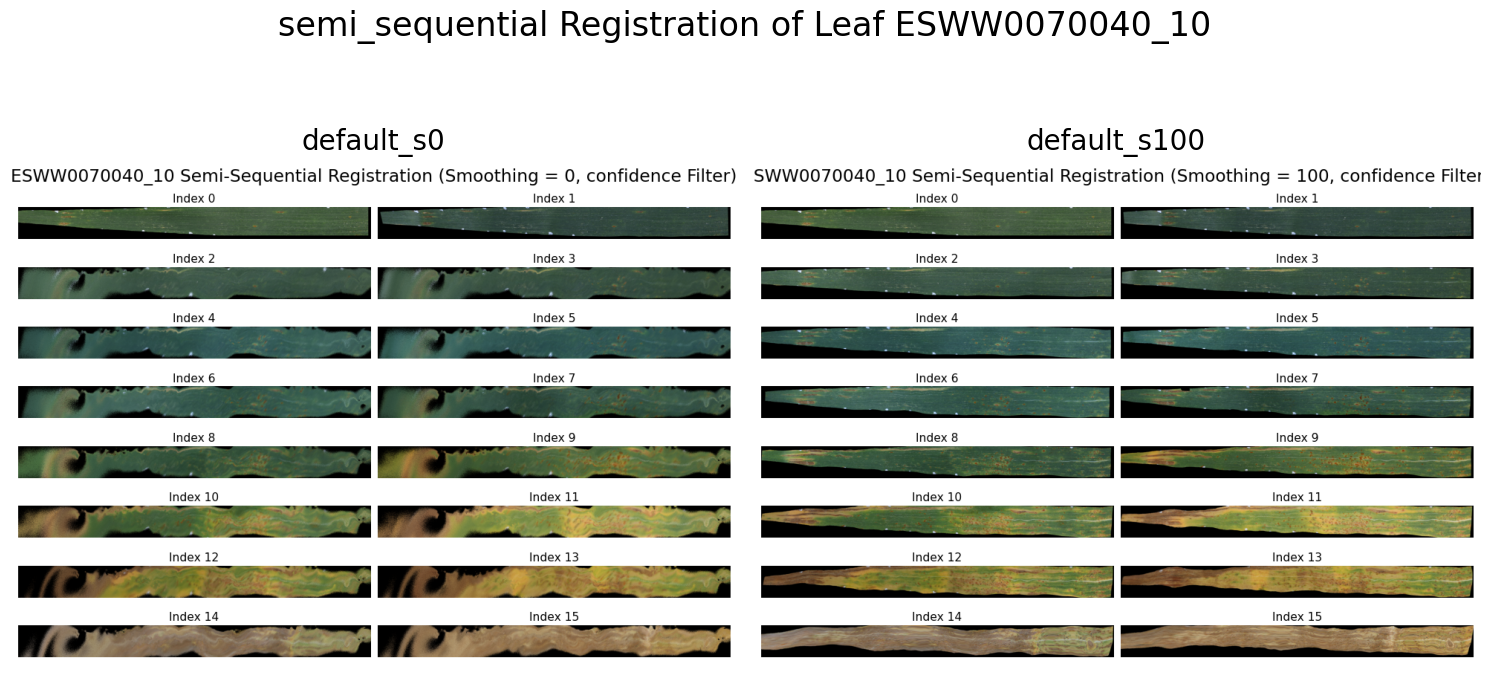

In [3]:
from PIL import Image
def fetch_seq_res(uid, method1='semi_sequential', method2='semi_sequential', config1='default_s0', config2='default_s100'):
    """
    method = 'semi_sequential', 'sequential', 'individual', 'piecewise_affine'
    config = 'default_s0', 'default_s100', 
        'min_dist_filter', 'cluster_filter', 'grid_filter', 
        'no_consistency',
        'with_markers', 'full_leaf', 'unrotated_roi', 'unrotated_roi_hom'
    """

    if method1 == 'piecewise_affine':
        img1_path = f'temp3/s0/{uid}_{method1}.png'
    elif config1 == 'default_s0':
        img1_path = f'temp3/s0/{uid}_{method1}_s0_confidence_filter.png'
        img1_path_alt = f'temp3/s0/{uid}_{method1}_s0.0_confidence_filter.png'
    elif config1 == 'default_s100':
        img1_path = f'temp3/s100/{uid}_{method1}_s100_confidence_filter.png'
    else:
        img1_path = f"temp3/{config1}/{uid}_{method1}_{config1}.png"

    if method2 == 'piecewise_affine':
        img2_path = f'temp3/s0/{uid}_{method2}.png'
    elif config2 == 'default_s0':
        img2_path = f'temp3/s0/{uid}_{method2}_s0_confidence_filter.png'
        img2_path_alt = f'temp3/s0/{uid}_{method2}_s0.0_confidence_filter.png'
    elif config2 == 'default_s100':
        img2_path = f'temp3/s100/{uid}_{method2}_s100_confidence_filter.png'
    else:
        img2_path = f"temp3/{config2}/{uid}_{method2}_{config2}.png"

    # img1 = Image.open(img1_path)
    # img2 = Image.open(img2_path)


    fig, (ax_1, ax_2) = plt.subplots(nrows=1, ncols=2, figsize=(15,8))

    if not os.path.isfile(img1_path):
        if config1 == "default_s0" and os.path.isfile(img1_path_alt):
            img1_path = img1_path_alt
        else:
            print(f"No file for {method1} {config1} registration for leaf {uid}")
            return fig

    if not os.path.isfile(img2_path):
        if config2 == "default_s0" and os.path.isfile(img2_path_alt):
            img2_path = img2_path_alt
        else:
            print(f"No file for {method2} {config2} registration for leaf {uid}")
            return fig
        
    img1 = Image.open(img1_path)
    img2 = Image.open(img2_path)

    ax_1.set_title(f'{config1}', fontsize=20)
    ax_1.axis('off')
    ax_1.imshow(img1)
    ax_2.set_title(f'{config2}', fontsize=20)
    ax_2.axis('off')
    ax_2.imshow(img2)

    if method1 == method2:
        fig.suptitle(f'{method1} Registration of Leaf {uid}', fontsize=24)
    else:
        fig.suptitle(f'{method1} vs {method2} Registration of Leaf {uid}', fontsize=24)
    plt.tight_layout()
    # plt.show()
    return fig

fig = fetch_seq_res(uid='ESWW0070040_10')
fig.show()

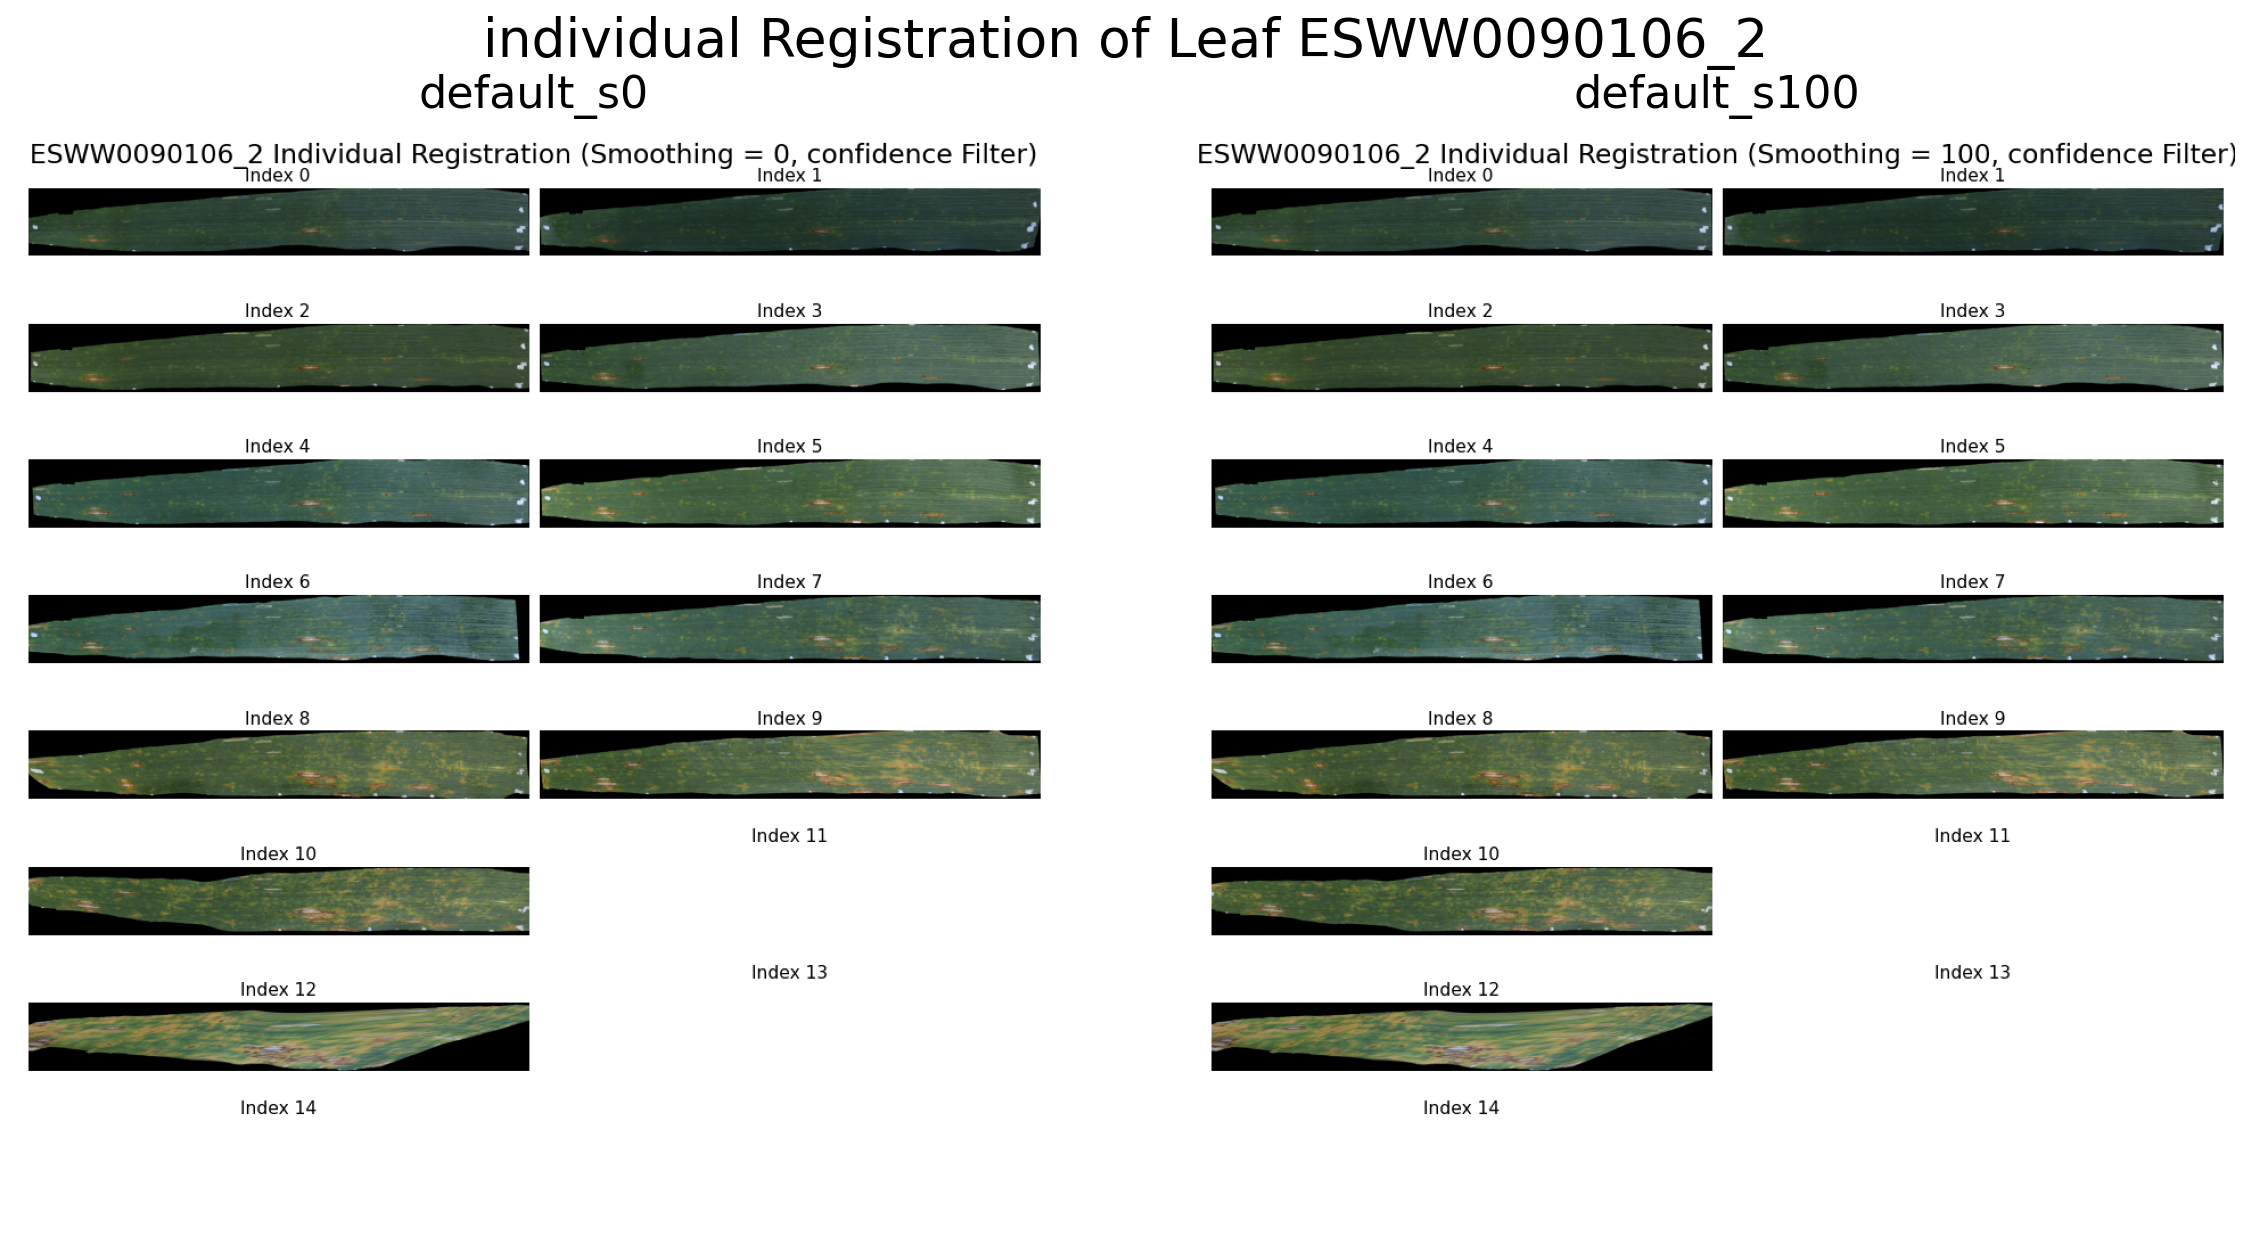

In [29]:
fig = fetch_seq_res(uid='ESWW0090106_2', method='individual')
fig.show()

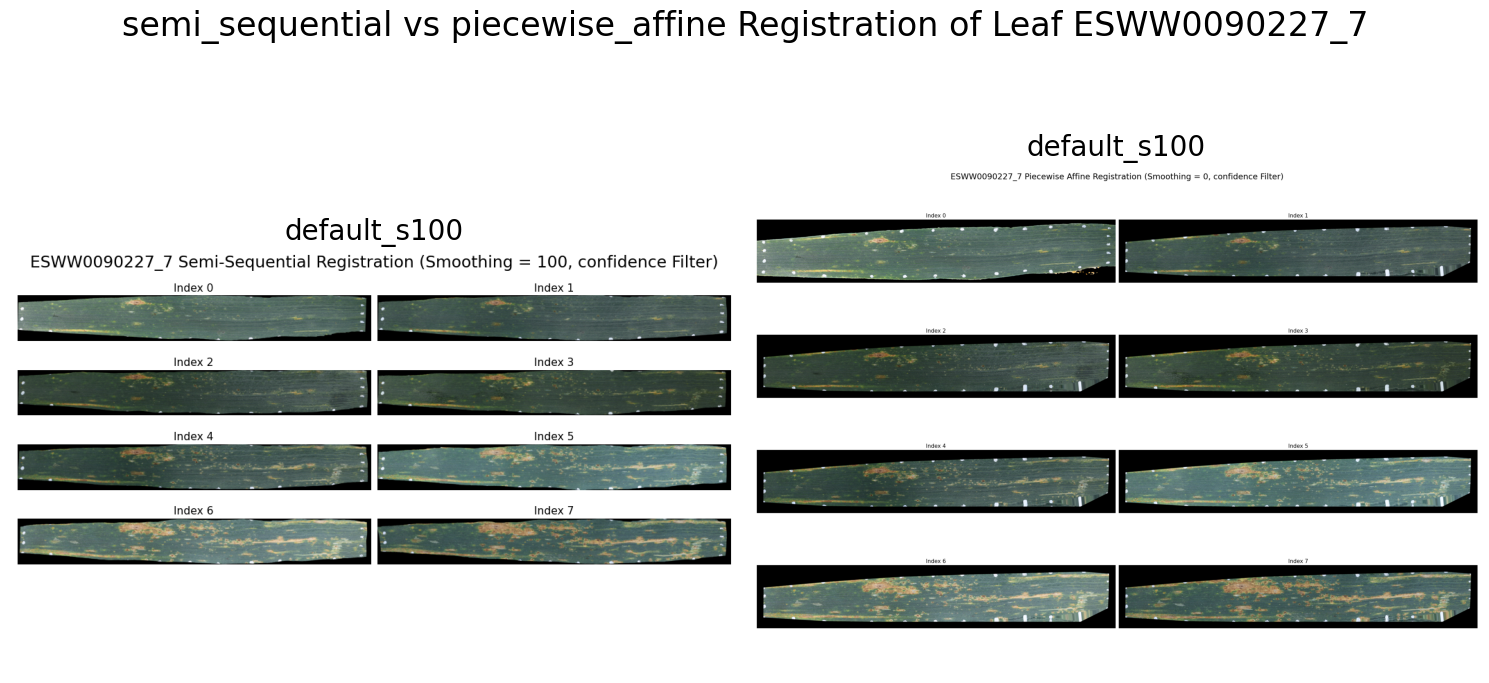

KeyboardInterrupt: 

In [9]:
from IPython.display import clear_output, display

n = 10
method1 = 'semi_sequential'
method2 = 'piecewise_affine'
# method2 = 'individual'
config1 = config2 = 'default_s100'
pause = 4
for uid in test_set[:20]:
    clear_output(wait=True) 
    fig = fetch_seq_res(uid, method1, method2, config1, config2)
    # fig.show()

    display(fig)
    plt.close(fig)

    time.sleep(pause)
    # plt.close()

In [ ]:
n = 5
method1 = 'semi_sequential'
# method2 = 'sequential'
method2 = 'piecewise_affine'
config1 = config2 = 'default_s100'
# filter = 'confidence'
data = test_set

results = {}

i = 0

plot_out = widgets.Output()
ui_out = widgets.Output()

display(plot_out, ui_out)

def show():
    global i

    if i >= len(data):
        with ui_out:
            clear_output(wait=True)
            print("Done!")
            print(results)
        return

    uid = data[i]

    # replace old figure
    with plot_out:
        clear_output(wait=True)

        fig = fetch_seq_res(uid, method1, method2, config1, config2)

        # fig.show()
        display(fig)
        plt.close(fig)

    # replace old buttons
    with ui_out:
        clear_output(wait=True)

        btn_good = widgets.Button(description="Good")
        btn_mid = widgets.Button(description="Mid")
        btn_bad = widgets.Button(description="Bad")
        btn_nan = widgets.Button(description="NaN")

        display(widgets.HBox([btn_good, btn_mid, btn_bad, btn_nan]))

    def classify(label):
        global i

        results.update({uid: label})

        i += 1
        show()

    btn_good.on_click(lambda b: classify("Good"))
    btn_mid.on_click(lambda b: classify("Mid"))
    btn_bad.on_click(lambda b: classify("Bad"))
    btn_nan.on_click(lambda b: classify("NaN"))

show()

Output()

Output()

In [ ]:
results

In [61]:
# semi_seq_quality = pd.DataFrame({"method": method, "uid": results.keys(), "quality": results.values()})
# semi_seq_quality.head()
# seq_quality = pd.DataFrame({"method": method2, "uid": results.keys(), "quality": results.values()})
# seq_quality.head()
indiv_quality = pd.DataFrame({"method": method2, "uid": results.keys(), "quality": results.values()})
indiv_quality.head()

,method,uid,quality
0,individual,ESWW0090151_6,Mid
1,individual,ESWW0070063_2,Bad
2,individual,ESWW0090106_2,Bad
3,individual,ESWW0090064_5,Bad
4,individual,ESWW0070173_5,Bad


In [66]:
# quality = pd.concat([indiv_quality, seq_quality, semi_seq_quality])
# quality.sample(5)

# Keep only id + renamed quality column
indiv_quality_temp = indiv_quality[["uid", "quality"]].rename(columns={"quality": "individual_quality"})
seq_quality_temp = seq_quality[["uid", "quality"]].rename(columns={"quality": "sequential_quality"})
semi_seq_quality_temp = semi_seq_quality[["uid", "quality"]].rename(columns={"quality": "semi_sequential_quality"})

# Merge everything on id
quality = (
    indiv_quality_temp
    .merge(seq_quality_temp, on="uid")
    .merge(semi_seq_quality_temp, on="uid")
)
quality.head()

,uid,individual_quality,sequential_quality,semi_sequential_quality
0,ESWW0090151_6,Mid,Good,Mid
1,ESWW0070063_2,Bad,Mid,Mid
2,ESWW0090106_2,Bad,Good,Mid
3,ESWW0090064_5,Bad,Bad,Bad
4,ESWW0070173_5,Bad,Bad,Bad


In [76]:
def convert_to_numeric(val):
    if val == "Good":
        return 1
    elif val == "Mid":
        return 0
    elif val == "Bad":
        return -1
    else:
        return None

def is_better(val1, val2):
    return convert_to_numeric(val1) > convert_to_numeric(val2)

# quality['semi_better_indiv'] = quality.apply(lambda row: is_better(row.semi_sequential_quality, row.individual_quality), axis=1)
# quality['semi_better_seq'] = quality.apply(lambda row: is_better(row.semi_sequential_quality, row.sequential_quality), axis=1)
quality['indiv_better'] = quality.apply(lambda row: is_better(row.individual_quality, row.semi_sequential_quality,), axis=1)
quality['seq_better'] = quality.apply(lambda row: is_better(row.sequential_quality, row.semi_sequential_quality,), axis=1)
quality.head()

,uid,individual_quality,sequential_quality,semi_sequential_quality,indiv_worse,seq_worse,semi_better_indiv,semi_better_seq,indiv_better,seq_better
0,ESWW0090151_6,Mid,Good,Mid,False,False,True,False,False,True
1,ESWW0070063_2,Bad,Mid,Mid,True,False,True,True,False,False
2,ESWW0090106_2,Bad,Good,Mid,True,False,True,False,False,True
3,ESWW0090064_5,Bad,Bad,Bad,False,False,True,True,False,False
4,ESWW0070173_5,Bad,Bad,Bad,False,False,True,True,False,False


In [ ]:
print(f"Number of Instances Individual Registration looks better: {quality.indiv_better.sum()}")
print(f"Number of Instances Sequential Registration looks better: {quality.seq_better.sum()}")

Number of Instances Individual Registration looks better: 9
Number of Instances Sequential Registration looks better: 10


In [85]:
print(f"Good Semi-Seq: {quality[quality.semi_sequential_quality == "Good"]['uid'].count()}")
print(f"Mid Semi-Seq: {quality[quality.semi_sequential_quality == "Mid"]['uid'].count()}")
print(f"Bad Semi-Seq: {quality[quality.semi_sequential_quality == "Bad"]['uid'].count()}")
print("------")
print(f"Good Seq: {quality[quality.sequential_quality == "Good"]['uid'].count()}")
print(f"Mid Seq: {quality[quality.sequential_quality == "Mid"]['uid'].count()}")
print(f"Bad Seq: {quality[quality.sequential_quality == "Bad"]['uid'].count()}")
print("------")
print(f"Good Indiv: {quality[quality.individual_quality == "Good"]['uid'].count()}")
print(f"Mid Indiv: {quality[quality.individual_quality == "Mid"]['uid'].count()}")
print(f"Bad Indiv: {quality[quality.individual_quality == "Bad"]['uid'].count()}")

Good Semi-Seq: 22
Mid Semi-Seq: 54
Bad Semi-Seq: 23
------
Good Seq: 22
Mid Seq: 48
Bad Seq: 29
------
Good Indiv: 8
Mid Indiv: 34
Bad Indiv: 57


## Smoothness 0 vs 100

In [19]:
df_full.head()

,leaf_uid,registration_method,leaf_scale,pre_rotated,markers,warp_consistency,filtering_strategy,smoothing,fixed_image,moving_image,MSE,MAPE,NCC,MI,MI_Skimage,SSIM,IoU,Hausdorff
0,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,1,0.030082,151.445633,0.083215,1.006809,1.083532,0.359662,0.950690,69.000000
1,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,2,0.022110,101.120529,0.110430,1.002640,1.057295,0.374180,0.957759,19.000000
2,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,3,0.032253,162.238388,-0.004962,1.005086,1.057885,0.283229,0.949796,17.000000
3,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,4,0.024807,103.195312,-0.002699,1.001393,1.056159,0.347806,0.939804,46.000000
4,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,5,0.019740,94.848923,-0.011554,1.000752,1.053308,0.320071,0.941029,22.807467


In [20]:
smoothness = 100
# metrics = ["MSE", "NCC", "MI", "MI_Skimage", "SSIM", "IoU", "Hausdorff"]
metrics = ["MSE", "NCC", "MI", "SSIM", "IoU", "Hausdorff"]
group_cols = ['registration_method', 'smoothing', 'fixed_image', 'moving_image']
methods = df_full["registration_method"].unique()
methods

array(['Baseline', 'Piecewise Affine', 'LoFTR + TPS Individual',
       'LoFTR + TPS Sequential', 'LoFTR + TPS Semi-Sequential'],
      dtype=object)

### Average over leaf for each time stamp

In [21]:
# average over leaf series for each index pair
df_agg = df_full.groupby(group_cols, dropna=False)[metrics].agg(["mean", "std"]).reset_index()
df_agg.columns = [ "_".join(col).rstrip("_") for col in df_agg.columns ]
df_agg.sample(5).sort_values(by=(group_cols))

,registration_method,smoothing,fixed_image,moving_image,MSE_mean,MSE_std,NCC_mean,NCC_std,MI_mean,MI_std,SSIM_mean,SSIM_std,IoU_mean,IoU_std,Hausdorff_mean,Hausdorff_std
9,Baseline,0.0,0,10,0.030599,0.022720,0.001716,0.024633,1.008633,0.013692,0.338431,0.065703,0.866614,0.103673,123.754628,143.772211
22,LoFTR + TPS Individual,0.0,0,7,0.022545,0.016276,0.057028,0.086523,1.007860,0.006522,0.399011,0.093816,0.897400,0.134824,87.617331,142.485630
27,LoFTR + TPS Individual,0.0,0,12,0.030903,0.019747,0.036730,0.063372,1.005584,0.005256,0.349734,0.092499,0.846873,0.158686,176.823662,259.829399
30,LoFTR + TPS Individual,0.0,0,15,0.064686,0.036270,0.016308,0.042185,1.005118,0.005185,0.292164,0.079407,0.697964,0.205229,228.375316,194.443827
42,LoFTR + TPS Individual,100.0,0,11,0.035723,0.027187,0.054175,0.102371,1.006030,0.007379,0.363848,0.091217,0.797568,0.233668,205.836422,324.217617


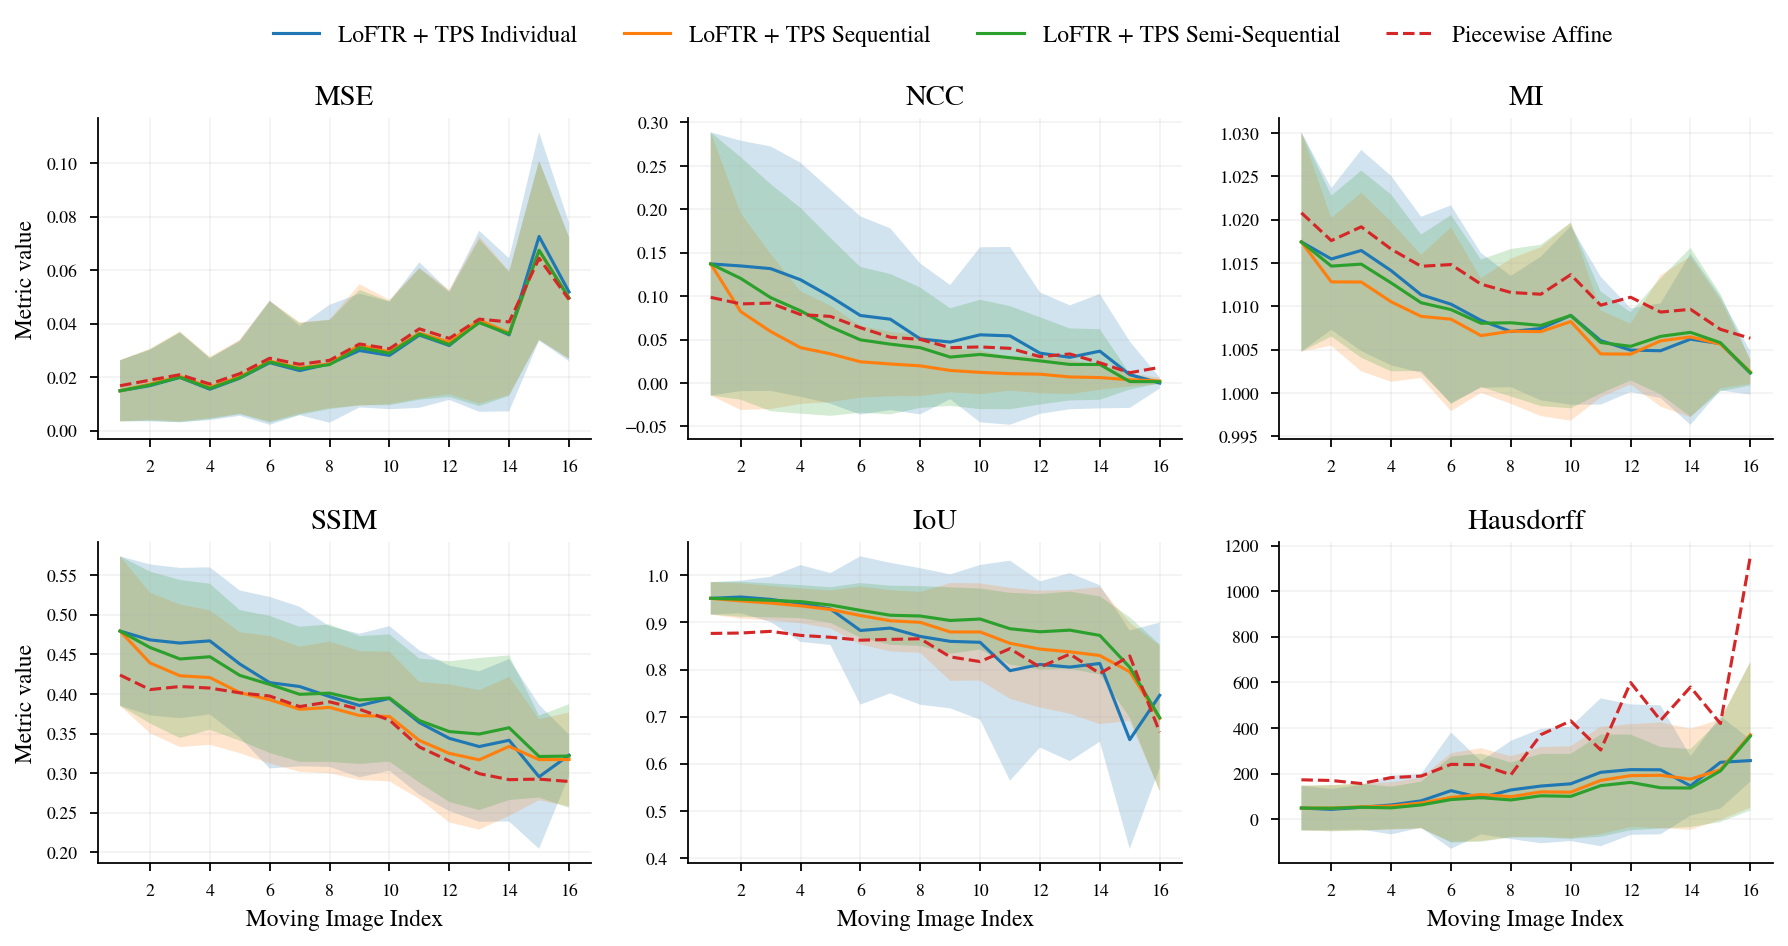

In [22]:
methods = ["LoFTR + TPS Individual", "LoFTR + TPS Sequential", "LoFTR + TPS Semi-Sequential", "Piecewise Affine"]#, "Baseline"]
# methods = ["LoFTR + TPS Semi-Sequential", "LoFTR + TPS Sequential", "LoFTR + TPS Individual", "Baseline"]
# methods = ["LoFTR + TPS Individual", "LoFTR + TPS Sequential", "LoFTR + TPS Semi-Sequential"]
# methods = ["Baseline", "Piecewise Affine"]

smoothing = 100
# smoothing = 0
n_metrics = len(metrics)

n_cols = 3
n_rows = math.ceil(n_metrics / n_cols)

# plt.style.use(['science', 'no-latex'])
plt.style.use('seaborn-v0_8-paper')

plt.rcParams.update({
    "figure.dpi": 160,
    "font.size": 14,
    'mathtext.fontset': 'stix',
    'font.family': 'STIXGeneral',
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    # "lines.linewidth": 2,
})


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharex=True,
    sharey=False,
    # dpi=300
)

for row in range(n_rows):
    axes[row, 0].set_ylabel("Metric value", fontsize=10.5)

for col in range(n_cols):
    axes[n_rows-1, col].set_xlabel("Moving Image Index", fontsize=10.5)

axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for method in methods:
        if method == "Piecewise Affine" or method == "Baseline":
            df_plot = df_agg[
                (df_agg["fixed_image"] == 0) &
                (df_agg["registration_method"] == method) &
                (df_agg["moving_image"] != 0)
            ].sort_values("moving_image")

            if df_plot.empty:
                continue

            x = df_plot["moving_image"]
            mean = df_plot[f"{metric}_mean"]
            std = df_plot[f"{metric}_std"]

            ax.plot(x, mean, label=method, linestyle='--')
                # ax.fill_between(x, mean - std, mean + std, alpha=0.2, label="_nolegend_")
            continue

        else:
            df_plot = df_agg[
                (df_agg["smoothing"] == smoothing) &
                (df_agg["fixed_image"] == 0) &
                (df_agg["registration_method"] == method) &
                (df_agg["moving_image"] != 0)
            ].sort_values("moving_image")

        if df_plot.empty:
            continue

        x = df_plot["moving_image"]
        mean = df_plot[f"{metric}_mean"]
        std = df_plot[f"{metric}_std"]

        ax.plot(x, mean, label=method)
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, label="_nolegend_")
        # if metric == "Hausdorff":
        #     ax.set_yscale('log')

    ax.set_title(metric, fontsize=13)
    ax.grid(True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(labelbottom=True)
    # ax.set_xlabel("Moving Image Index")

# hide unused subplots
for ax in axes[len(metrics):]:
    ax.set_visible(False)
    

# shared y-label
# axes[0].set_ylabel("Metric value")

# put legend far right outside
fig.legend(
    methods,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.),
    fontsize=10.5,
    ncol=len(methods),
    frameon=False,
)

# fig.suptitle(f"Smoothing = {smoothing}", fontsize=16)

# tighten layout to remove empty space
fig.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()


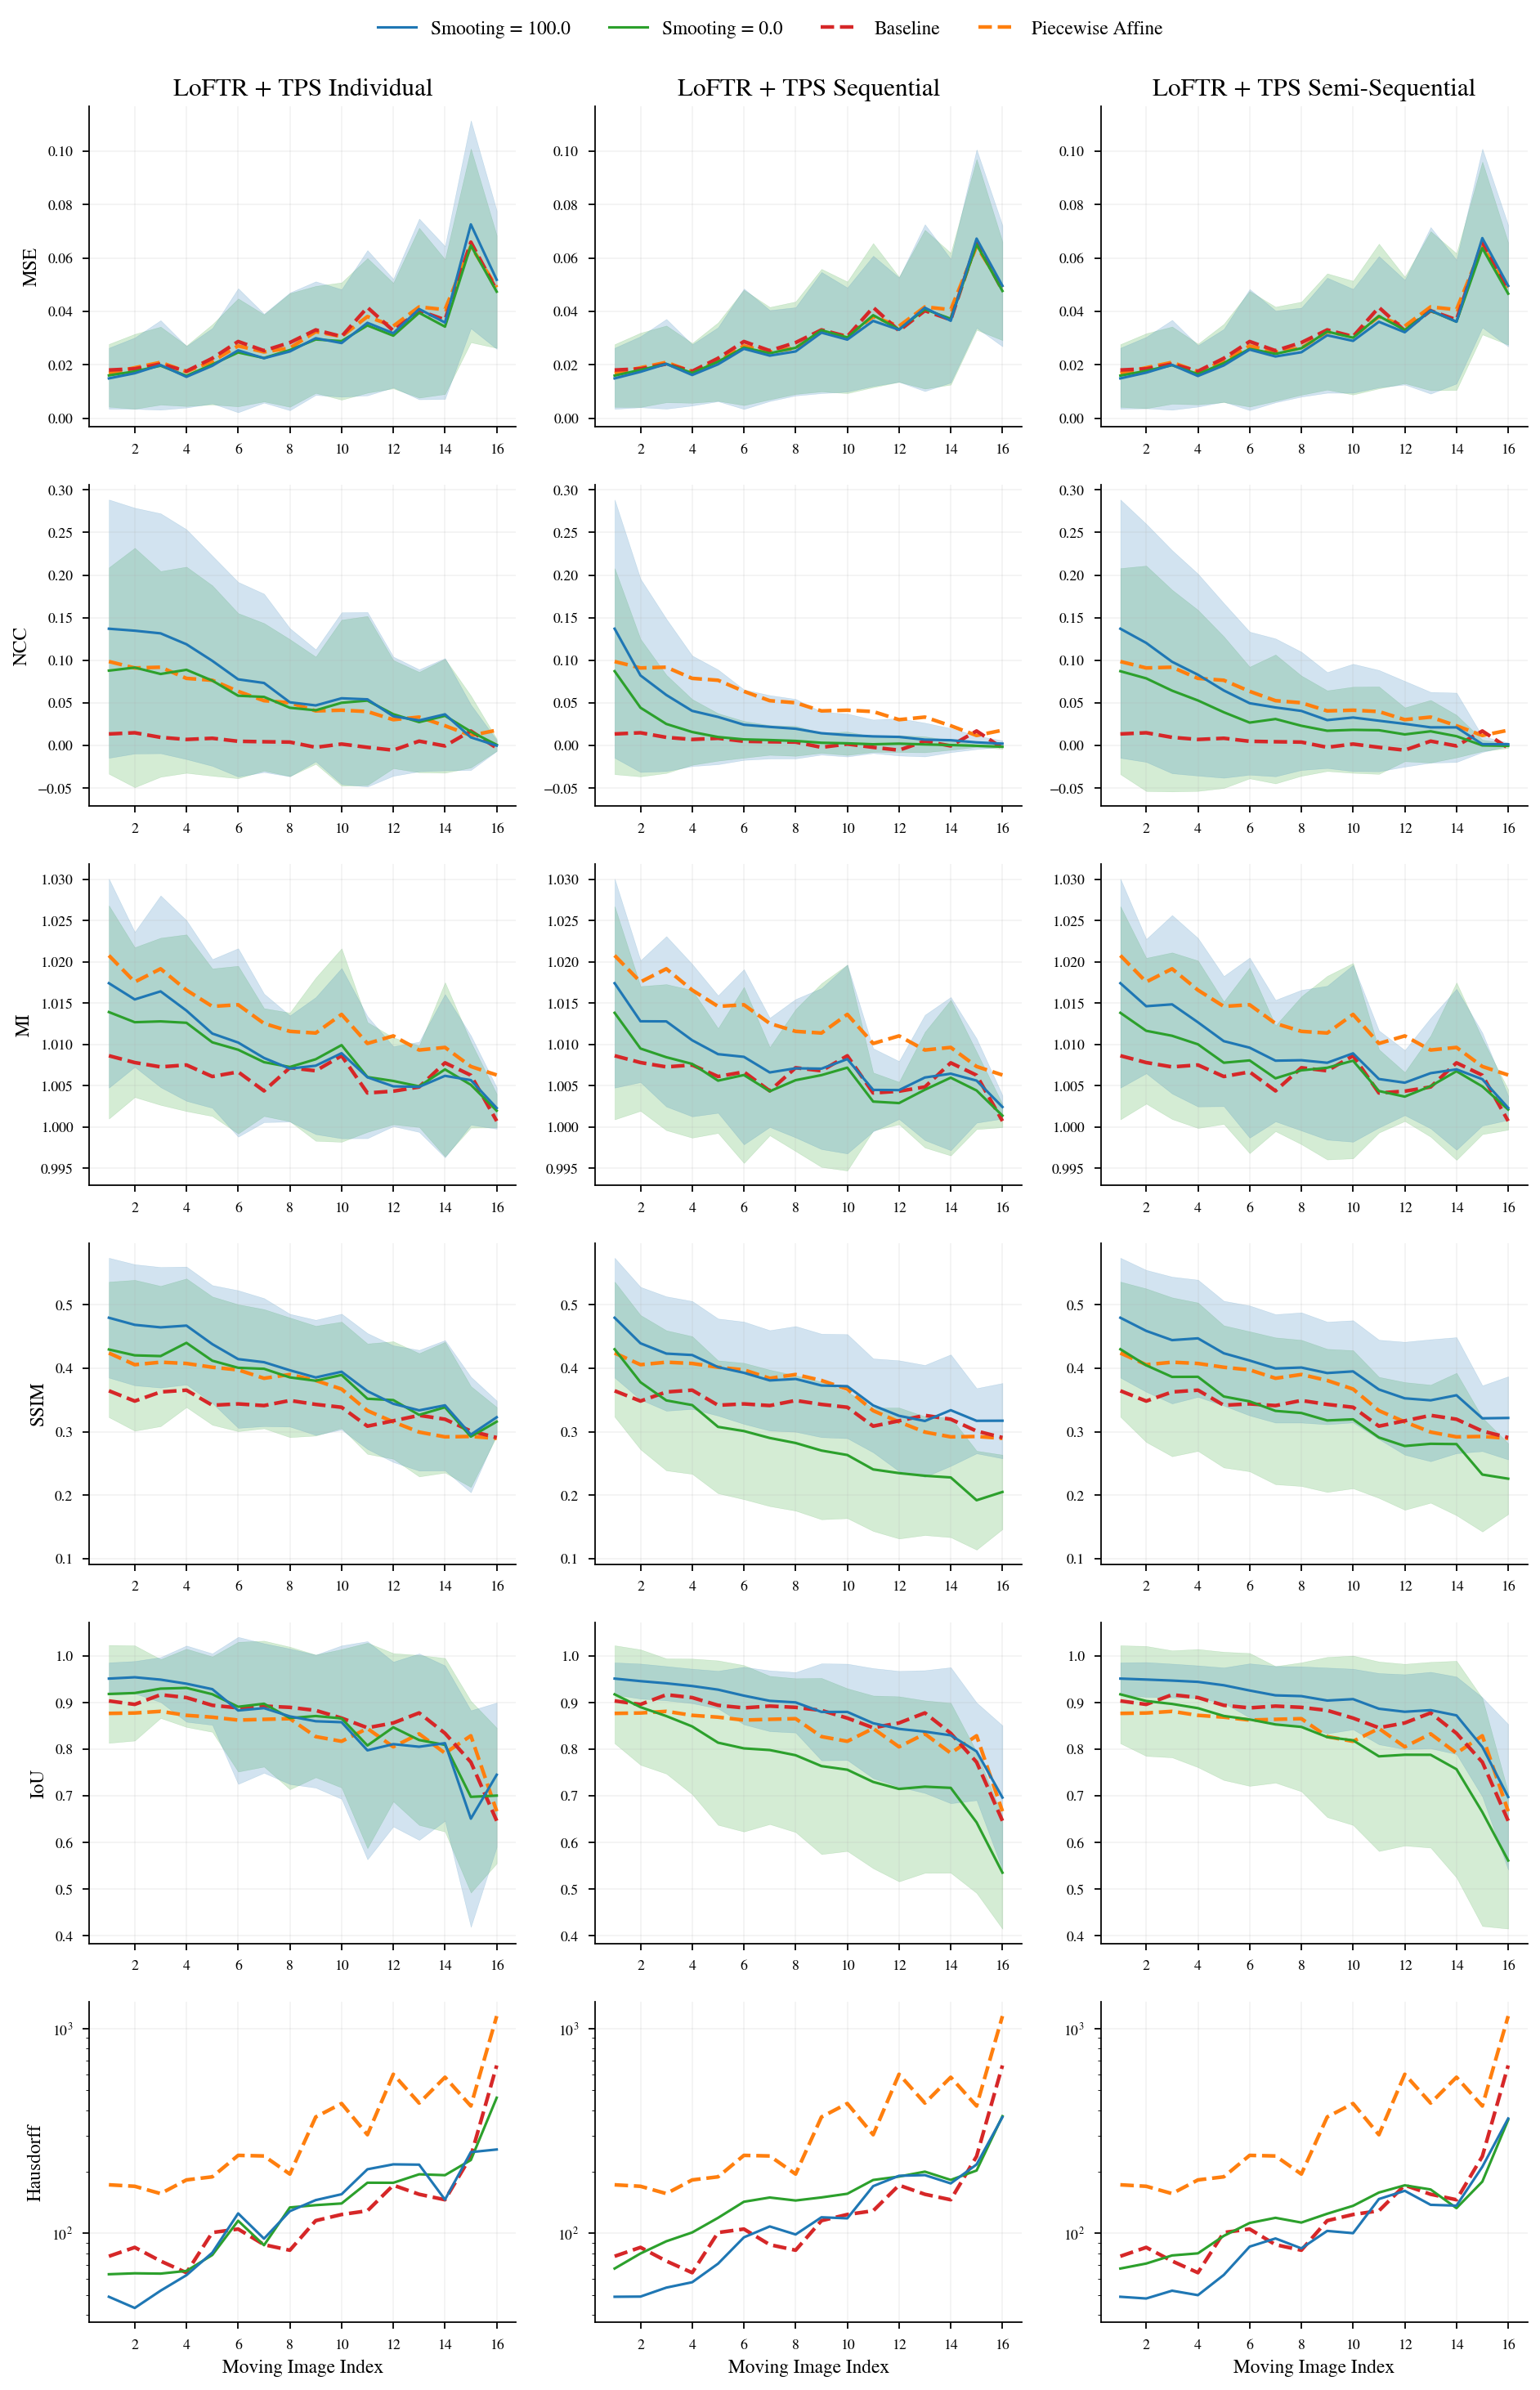

In [23]:
# metrics = ["metric_a", "metric_b", "metric_c"]

methods = ["LoFTR + TPS Individual", "LoFTR + TPS Sequential", "LoFTR + TPS Semi-Sequential"]
method_colors = {
    "LoFTR + TPS Individual": "tab:blue",
    "LoFTR + TPS Sequential": "tab:olive",
    "LoFTR + TPS Semi-Sequential": "tab:green",
    "Piecewise Affine": "tab:orange",
    "Baseline": "tab:red",
}
smooth_colors = {100: "tab:blue", 0.0: "tab:green"}

smooth_styles = {
    100: "-",
    0: "--",
}


baseline_style = ":"

# baseline = "Baseline"
baselines = ["Piecewise Affine", "Baseline"]
# baseline_df = df_agg[df_agg["registration_method"] == baseline]

plt.style.use('seaborn-v0_8-paper')

plt.rcParams.update({
    "figure.dpi": 160,
    "font.size": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    # "lines.linewidth": 2,
})

fig, axes = plt.subplots(
    nrows=len(metrics),
    ncols=len(methods),
    figsize=(4 * len(methods), 3 * len(metrics)),
    sharex=True,
    sharey="row",
)

for row, metric in enumerate(metrics):
    for col, method in enumerate(methods):

        ax = axes[row, col]

        for baseline in baselines:
            # baseline
            baseline_df = df_agg[df_agg["registration_method"] == baseline]
            ax.plot(
                baseline_df["moving_image"],
                baseline_df[f"{metric}_mean"],
                label=baseline,
                linewidth=2,
                linestyle="--",
                color=method_colors[baseline],
            )

            x = baseline_df["moving_image"]
            mean = baseline_df[f"{metric}_mean"]
            std = baseline_df[f"{metric}_std"]        

            # ax.plot(x, mean, label=method)
            # ax.fill_between(x, mean - std, mean + std, alpha=0.0, label="_nolegend_")


        # fancy method variants
        method_df = df_agg[df_agg["registration_method"] == method]

        for hp, hp_df in method_df.groupby("smoothing", dropna=False):
            
            ax.plot(
                hp_df["moving_image"],
                hp_df[f"{metric}_mean"],
                # label=f"{method} | s={hp}",
                label=f"Smooting = {hp}",
                color=smooth_colors[hp],
            )

            x = hp_df["moving_image"]
            mean = hp_df[f"{metric}_mean"]
            std = hp_df[f"{metric}_std"]        

            # ax.plot(x, mean, label=method)
            if metric != "Hausdorff":
                ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=smooth_colors[hp], label="_nolegend_")

        

        if row == 0:
            ax.set_title(method, fontsize=14)

        if metric == "Hausdorff":
            ax.set_yscale('log')
        
        ax.tick_params(labelleft=True)
        ax.tick_params(labelbottom=True)

        if col == 0:
            ax.set_ylabel(metric, fontsize=10.5)

        if row == len(metrics) - 1:
            ax.set_xlabel("Moving Image Index", fontsize=10.5)

        # ax.legend()

handles, labels = axes[0,0].get_legend_handles_labels()
handles.reverse()
labels.reverse()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(labels),
    frameon=False,
    fontsize=10.5
)        

    

plt.tight_layout()
plt.show()

### Average over time stamps per leaf

In [91]:
df_full.head()

,leaf_uid,registration_method,leaf_scale,pre_rotated,markers,warp_consistency,filtering_strategy,smoothing,fixed_image,moving_image,MSE,MAPE,NCC,MI,MI_Skimage,SSIM,IoU,Hausdorff
0,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,1,0.030082,151.445633,0.083215,1.006809,1.083532,0.359662,0.950690,69.000000
1,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,2,0.022110,101.120529,0.110430,1.002640,1.057295,0.374180,0.957759,19.000000
2,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,3,0.032253,162.238388,-0.004962,1.005086,1.057885,0.283229,0.949796,17.000000
3,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,4,0.024807,103.195312,-0.002699,1.001393,1.056159,0.347806,0.939804,46.000000
4,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,5,0.019740,94.848923,-0.011554,1.000752,1.053308,0.320071,0.941029,22.807467


In [109]:
df = df_full.merge(reg_counts.rename(columns={'Successful Piecewise Affine Registrations': 'num_reg'})[["leaf_uid", 'num_reg']], on="leaf_uid")
df.head()

,leaf_uid,registration_method,leaf_scale,pre_rotated,markers,warp_consistency,filtering_strategy,smoothing,fixed_image,moving_image,MSE,MAPE,NCC,MI,MI_Skimage,SSIM,IoU,Hausdorff,num_reg
0,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,1,0.030082,151.445633,0.083215,1.006809,1.083532,0.359662,0.950690,69.000000,10
1,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,2,0.022110,101.120529,0.110430,1.002640,1.057295,0.374180,0.957759,19.000000,10
2,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,3,0.032253,162.238388,-0.004962,1.005086,1.057885,0.283229,0.949796,17.000000,10
3,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,4,0.024807,103.195312,-0.002699,1.001393,1.056159,0.347806,0.939804,46.000000,10
4,ESWW0090151_6,Baseline,roi,True,False,True,confidence,0.0,0,5,0.019740,94.848923,-0.011554,1.000752,1.053308,0.320071,0.941029,22.807467,10


In [159]:
smoothness = 100
metrics = ["MSE", "NCC", "MI", "MI_Skimage", "SSIM", "IoU", "Hausdorff"]
group_cols = ['registration_method', 'smoothing', 'fixed_image', 'moving_image']
# methods = df_full["registration_method"].unique()
# methods

df_long = df.melt(
    id_vars=["leaf_uid", "registration_method", 'smoothing', "moving_image", "num_reg"],
    value_vars=metrics,
    var_name="metric",
    value_name="value",
    # dropna=False
)

# average over time stamps
agg = (
    df_long.groupby(
        ["leaf_uid", "registration_method", 'smoothing', "metric", "num_reg"], dropna=False
    )["value"]
    .mean()
    .reset_index()
)
agg.sample(5)

,leaf_uid,registration_method,smoothing,metric,num_reg,value
2750,ESWW0090064_5,LoFTR + TPS Semi-Sequential,100.0,SSIM,9,0.433873
3288,ESWW0090112_2,LoFTR + TPS Sequential,100.0,NCC,10,0.013342
4762,ESWW0090211_5,LoFTR + TPS Semi-Sequential,100.0,MI,12,1.009313
3032,ESWW0090094_3,Baseline,0.0,IoU,11,0.902645
3143,ESWW0090106_2,LoFTR + TPS Individual,0.0,Hausdorff,11,51.163564


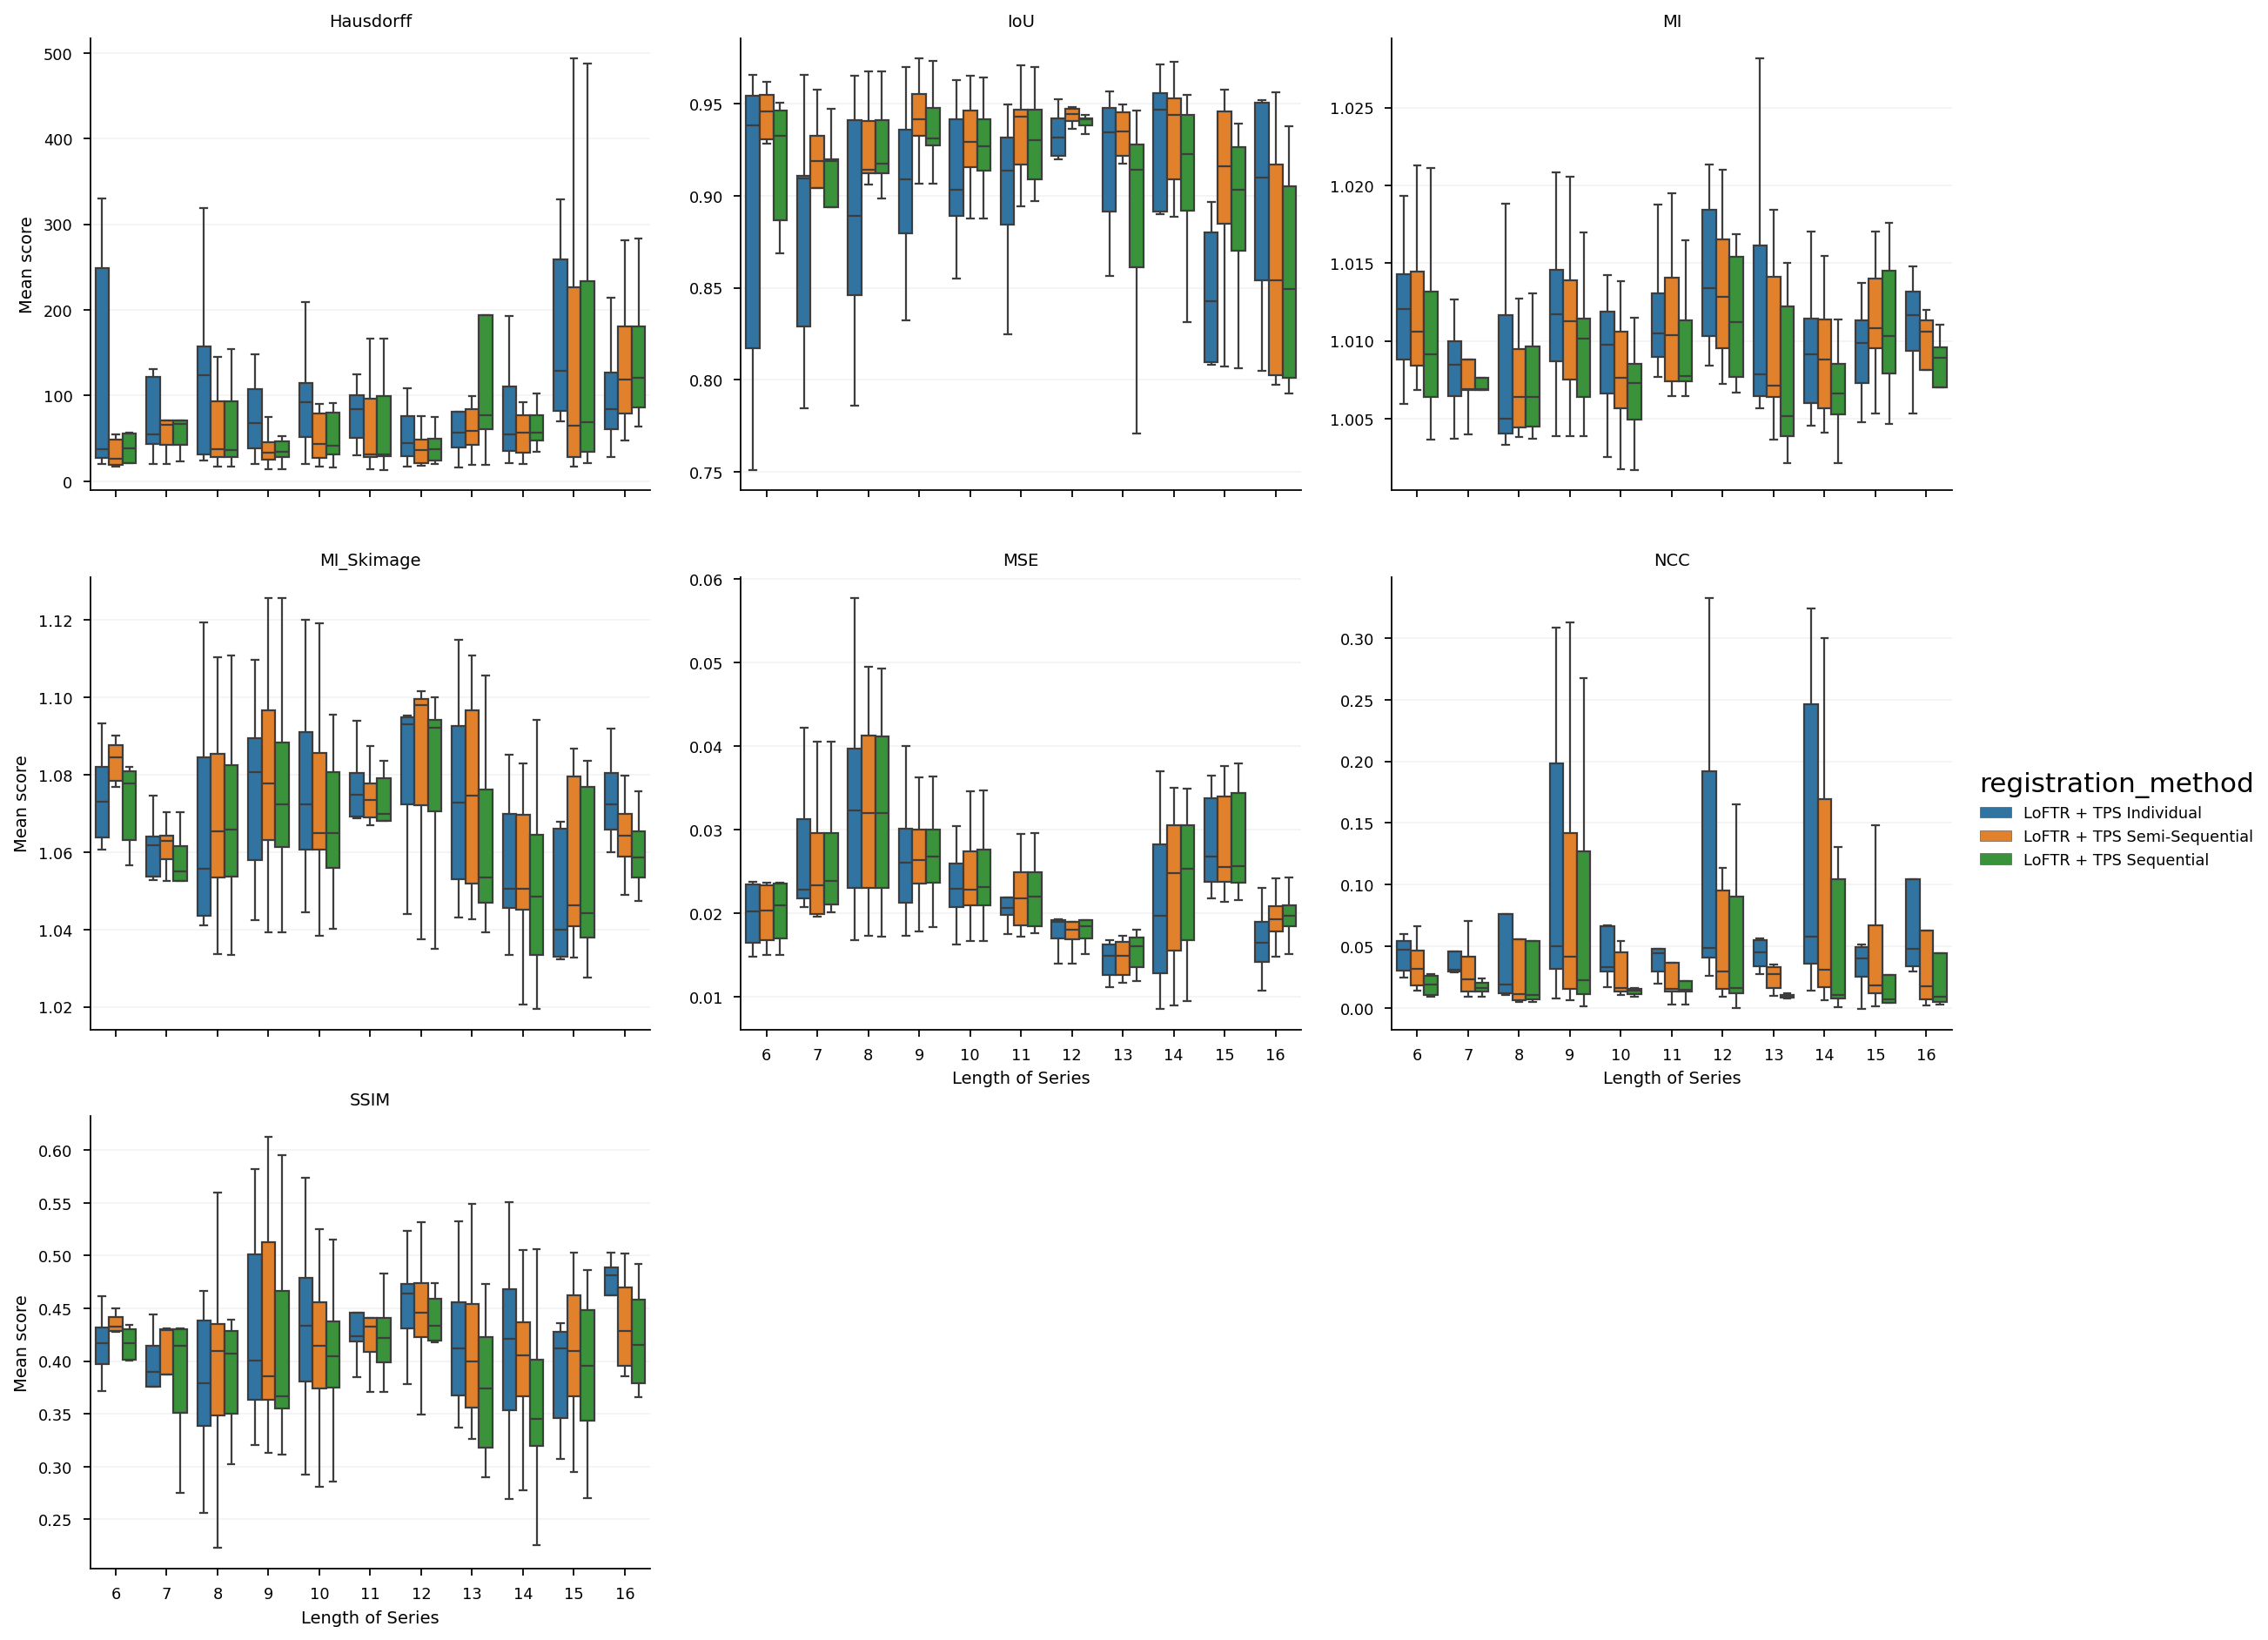

In [129]:
# import statsmodels
g = sns.catplot(
    data=agg,
    x="num_reg",
    y="value",
    hue="registration_method",
    col="metric",
    kind="box",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=False,
    dodge=True,
    showfliers=False
)


g.set_axis_labels("Length of Series", "Mean score")
g.set_titles("{col_name}")

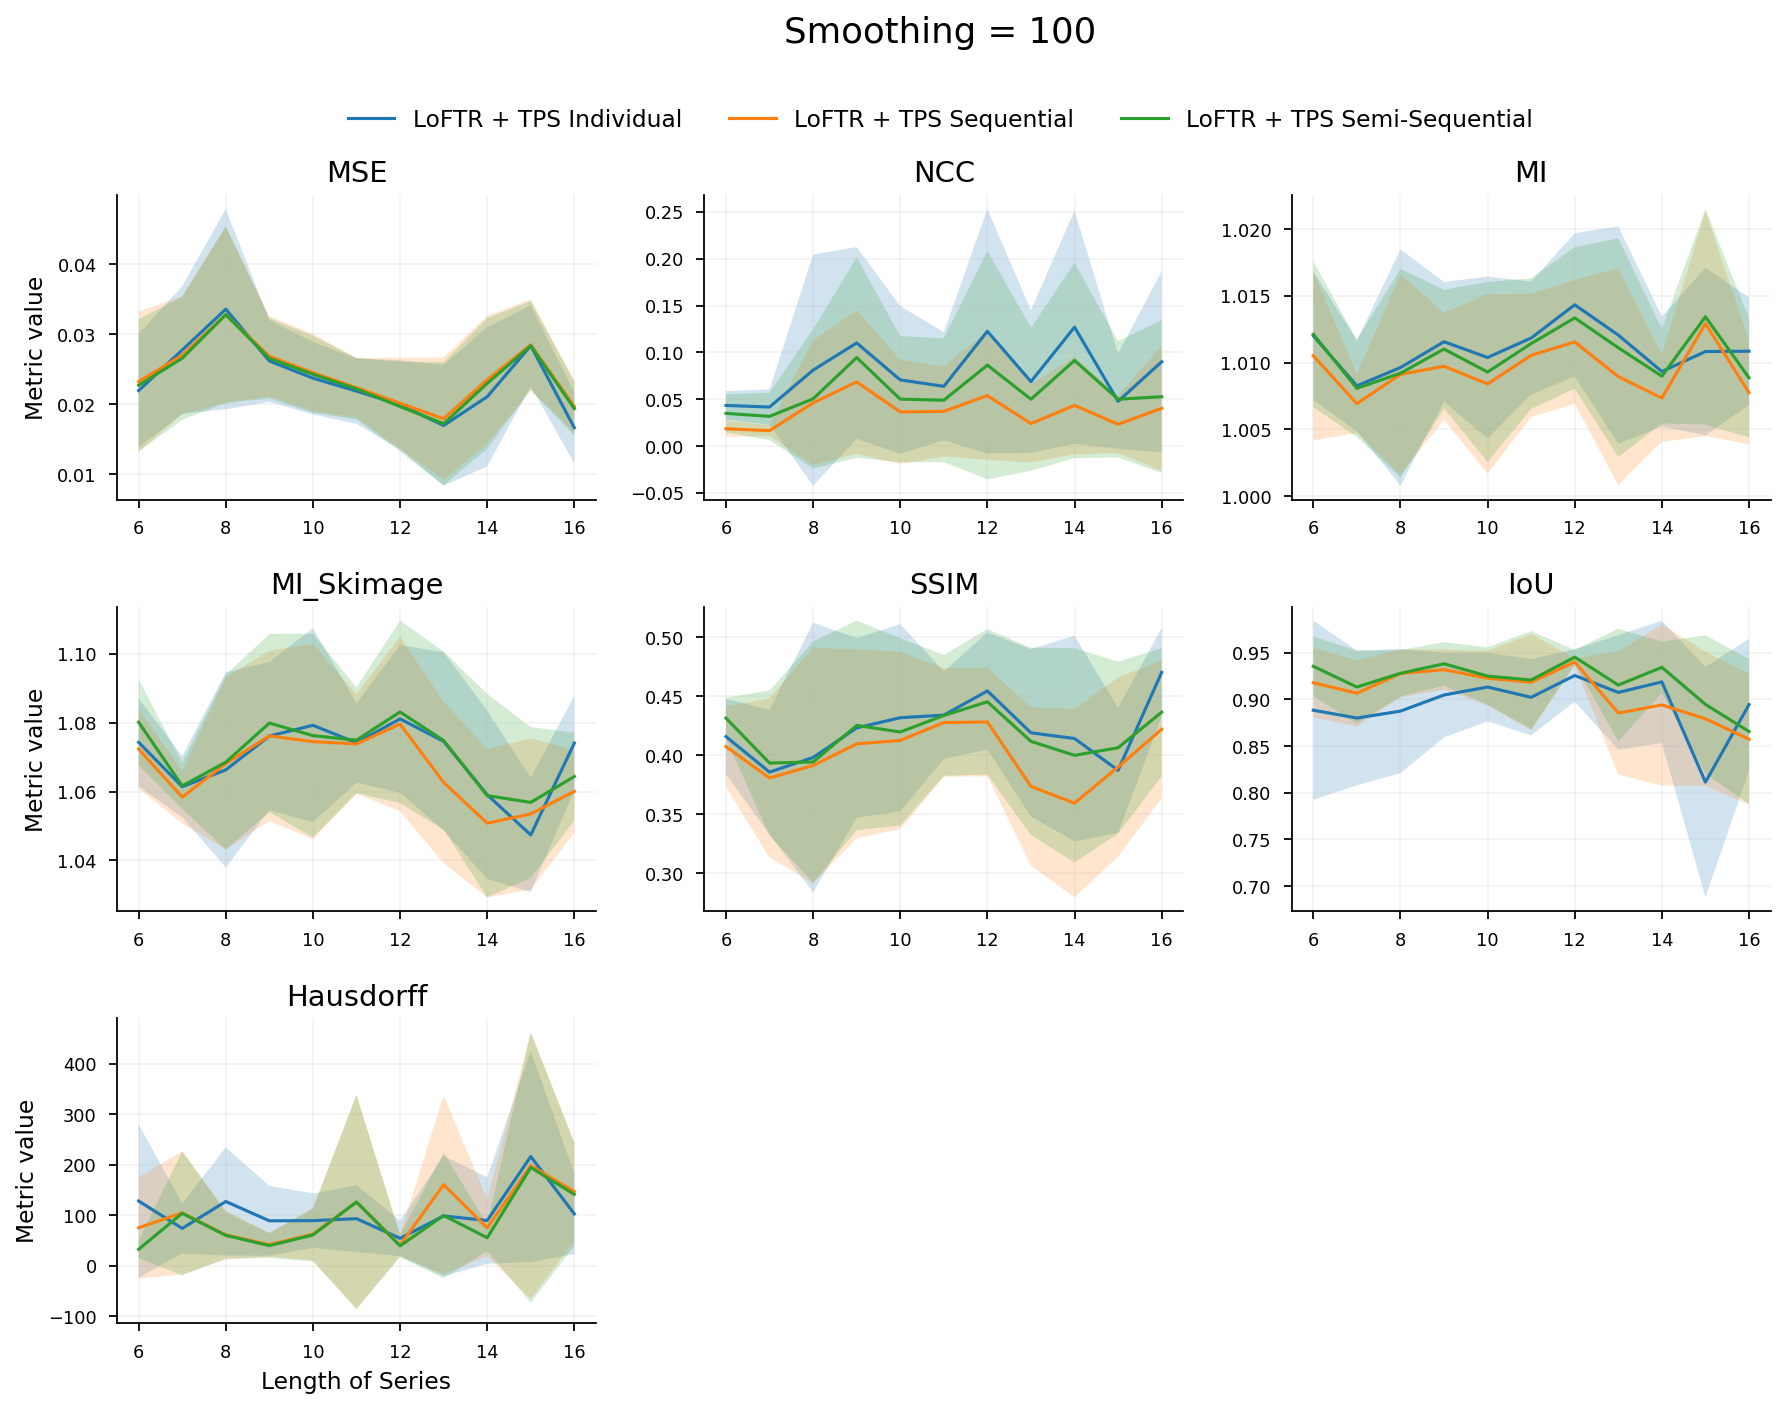

In [150]:
# methods = ["LoFTR + TPS Semi-Sequential", "LoFTR + TPS Sequential", "LoFTR + TPS Individual", "Piecewise Affine"]
# methods = ["LoFTR + TPS Semi-Sequential", "LoFTR + TPS Sequential", "LoFTR + TPS Individual", "Baseline"]
methods = ["LoFTR + TPS Individual", "LoFTR + TPS Sequential", "LoFTR + TPS Semi-Sequential"]
# methods = ["Baseline", "Piecewise Affine"]

smoothing = 100
# smoothing = 0
n_metrics = len(metrics)

n_rows = 3
n_cols = math.ceil(n_metrics / n_rows)

# plt.style.use(['science', 'no-latex'])
plt.style.use('seaborn-v0_8-paper')

plt.rcParams.update({
    "figure.dpi": 160,
    "font.size": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    # "lines.linewidth": 2,
})


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharex=True,
    sharey=False,
    # dpi=300
)

for row in range(n_rows):
    axes[row, 0].set_ylabel("Metric value", fontsize=10.5)

for col in range(n_cols):
    axes[n_rows-1, col].set_xlabel("Length of Series", fontsize=10.5)

axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for method in methods:
        if method == "Piecewise Affine" or method == "Baseline":
            df_plot = agg[
                (agg["registration_method"] == method)
            ].sort_values("num_reg")
        else:
            df_plot = agg[
                (agg["smoothing"] == smoothing) &
                (agg["registration_method"] == method)
            ].sort_values("num_reg")

        if df_plot.empty:
            continue
        
        # print(df_plot.head())

        x = df_plot["num_reg"].unique()
        mean = df_plot[df_plot.metric == metric].groupby(['num_reg'])['value'].mean()
        std = df_plot[df_plot.metric == metric].groupby(['num_reg'])['value'].std()

        ax.plot(x, mean, label=method)
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, label="_nolegend_")
        # if metric == "Hausdorff":
        #     ax.set_yscale('log')

    ax.set_title(metric, fontsize=13)
    ax.grid(True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(labelbottom=True)
    # ax.set_xlabel("Moving Image Index")

# hide unused subplots
for ax in axes[len(metrics):]:
    ax.set_visible(False)
    

# shared y-label
# axes[0].set_ylabel("Metric value")

# put legend far right outside
fig.legend(
    methods,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    fontsize=10.5,
    ncol=len(methods),
    frameon=False,
)

fig.suptitle(f"Smoothing = {smoothing}", fontsize=16)

# tighten layout to remove empty space
fig.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()


### Full Average

In [9]:
# smoothness = 100
metrics = ["MSE", "NCC", "MI", "MI_Skimage", "SSIM", "IoU", "Hausdorff"]
metrics = ["MSE", "NCC", "MI", "SSIM", "IoU", "Hausdorff"]
group_cols = ['registration_method', 'smoothing']
# methods = df_full["registration_method"].unique()
# methods

full_avg = df_full.groupby(group_cols, dropna=False)[metrics].agg(["mean", "std"]).reset_index()
full_avg

registration_method smoothing       MSE                 NCC  \
                                              mean       std      mean   
0                     Baseline       0.0  0.026366  0.020093  0.006158   
1       LoFTR + TPS Individual       0.0  0.023825  0.019923  0.064960   
2       LoFTR + TPS Individual     100.0  0.023827  0.020955  0.087363   
3  LoFTR + TPS Semi-Sequential       0.0  0.025034  0.020191  0.040882   
4  LoFTR + TPS Semi-Sequential     100.0  0.024188  0.019961  0.065532   
5       LoFTR + TPS Sequential       0.0  0.025403  0.020195  0.018990   
6       LoFTR + TPS Sequential     100.0  0.024556  0.020039  0.041371   
7             Piecewise Affine       NaN  0.025815  0.020359  0.064545   

                   MI                SSIM                 IoU            \
        std      mean       std      mean       std      mean       std   
0  0.035509  1.006779  0.008805  0.345058  0.081041  0.887073  0.093298   
1  0.105417  1.009932  0.009788  0.398957  0.104194  0.889745  0.134991   
2  0.121748  1.011044  0.010320  0.421736  0.104709  0.894867  0.137958   
3  0.090760  1.008490  0.009883  0.350804  0.120959  0.855522  0.156174   
4  0.107165  1.010656  0.009973  0.416544  0.095937  0.922073  0.064223   
5  0.056453  1.007012  0.009357  0.310796  0.119450  0.811016  0.171467   
6  0.081304  1.009453  0.009687  0.397153  0.093394  0.907907  0.083347   
7  0.064998  1.014624  0.009677  0.384961  0.079202  0.856504  0.109928   

    Hausdorff              
         mean         std  
0  102.751792  157.503629  
1  106.710212  189.312372  
2  106.673818  197.402712  
3  108.331719  145.046811  
4   84.224719  158.840586  
5  129.572330  147.385101  
6   96.134599  171.586867  
7  264.002155  544.437040

In [207]:
metrics

['MSE', 'NCC', 'MI', 'MI_Skimage', 'SSIM', 'IoU', 'Hausdorff']

In [10]:
# for exporting to latex
# df_rounded = full_avg.round(4)
# df_rounded
df_latex = full_avg.copy()
df_latex.columns = [ "_".join(col).rstrip("_") for col in df_latex.columns ]
df_latex.sort_values(by=(group_cols))


df_latex["registration_method"] = df_latex["registration_method"].str.removeprefix("LoFTR + TPS ")
# df_latex["smoothing"] = df_latex["smoothing"].astype("Int64")
df_latex["smoothing"] = (
    df_latex["smoothing"]
    .fillna("-")                      
    .apply(lambda x: int(x) if x != "-" else x)
)
df_latex.loc[df_latex["registration_method"] == "Baseline", 'smoothing'] = '-'

methods = ['Baseline', 'Piecewise Affine', 'Individual', 'Sequential', 'Semi-Sequential']
df_latex["registration_method"] = pd.Categorical(
    df_latex["registration_method"],
    categories=methods,
    ordered=True
)

df_latex = df_latex.sort_values("registration_method")


# df_latex.loc[]

precision = {
    # 'MSE': {"mean": 4, "std": 3}, 
    # 'NCC': {"mean": 4, "std": 2}, 
    # 'MI': {"mean": 4, "std": 4}, 
    # 'MI_Skimage': {"mean": 4, "std": 3}, 
    # 'SSIM': {"mean": 3, "std": 3}, 
    # 'IoU': {"mean": 3, "std": 3}, 
    'Hausdorff': {"mean": 2, "std": 1},
}

default_mean = 4
default_std = 3

for m in metrics:
    mean_digits = precision.get(m, {}).get("mean", default_mean)
    std_digits = precision.get(m, {}).get("std", default_std)

    df_latex[f"{m}"] = (
        df_latex[f"{m}_mean"].map(lambda x: f"{x:.{mean_digits}f}") #+
        # " $\\pm$ " +
        # df_latex[f"{m}_std"].map(lambda x: f"{x:.{std_digits}f}")
    )

df_latex = df_latex[['registration_method', 'smoothing'] + metrics].set_index(["registration_method", "smoothing"])
df_latex
# df_latex[['registration_method', 'smoothing'] + metrics]
print( df_latex.to_latex(escape=False, index=True, column_format='lrccccccc', multirow=True, bold_rows=False, sparsify=True))

\begin{tabular}{lrccccccc}
\toprule
 &  & MSE & NCC & MI & SSIM & IoU & Hausdorff \\
registration_method & smoothing &  &  &  &  &  &  \\
\midrule
Baseline & - & 0.0264 & 0.0062 & 1.0068 & 0.3451 & 0.8871 & 102.75 \\
\cline{1-8}
Piecewise Affine & - & 0.0258 & 0.0645 & 1.0146 & 0.3850 & 0.8565 & 264.00 \\
\cline{1-8}
\multirow[t]{2}{*}{Individual} & 0 & 0.0238 & 0.0650 & 1.0099 & 0.3990 & 0.8897 & 106.71 \\
 & 100 & 0.0238 & 0.0874 & 1.0110 & 0.4217 & 0.8949 & 106.67 \\
\cline{1-8}
\multirow[t]{2}{*}{Sequential} & 0 & 0.0254 & 0.0190 & 1.0070 & 0.3108 & 0.8110 & 129.57 \\
 & 100 & 0.0246 & 0.0414 & 1.0095 & 0.3972 & 0.9079 & 96.13 \\
\cline{1-8}
\multirow[t]{2}{*}{Semi-Sequential} & 0 & 0.0250 & 0.0409 & 1.0085 & 0.3508 & 0.8555 & 108.33 \\
 & 100 & 0.0242 & 0.0655 & 1.0107 & 0.4165 & 0.9221 & 84.22 \\
\cline{1-8}
\bottomrule
\end{tabular}



In [ ]:

full_avg.columns = [ "_".join(col).rstrip("_") for col in full_avg.columns ]
full_avg.sort_values(by=(group_cols))

full_avg_melt = full_avg.melt(
    id_vars=["registration_method", 'smoothing'],
    value_vars=[f"{m}_mean" for m in metrics] + [f"{m}_std" for m in metrics],
    var_name="metric_stat",
    value_name="value",
    # dropna=False
)

full_avg_melt.head()


,registration_method,smoothing,metric_stat,value
0,Baseline,0.0,MSE_mean,0.026366
1,LoFTR + TPS Individual,0.0,MSE_mean,0.023825
2,LoFTR + TPS Individual,100.0,MSE_mean,0.023827
3,LoFTR + TPS Semi-Sequential,0.0,MSE_mean,0.025034
4,LoFTR + TPS Semi-Sequential,100.0,MSE_mean,0.024188


In [ ]:
full_avg_melt[["metric", "stat"]] = full_avg_melt["metric_stat"].str.rsplit("_", n=1, expand=True)
full_avg_melt.head()

,registration_method,smoothing,metric_stat,value,metric,stat
0,Baseline,0.0,MSE_mean,0.026366,MSE,mean
1,LoFTR + TPS Individual,0.0,MSE_mean,0.023825,MSE,mean
2,LoFTR + TPS Individual,100.0,MSE_mean,0.023827,MSE,mean
3,LoFTR + TPS Semi-Sequential,0.0,MSE_mean,0.025034,MSE,mean
4,LoFTR + TPS Semi-Sequential,100.0,MSE_mean,0.024188,MSE,mean


In [172]:
df_plot = (
    full_avg_melt
    .pivot_table(
        index=["registration_method", "smoothing", "metric"],
        columns="stat",
        values="value"
    )
    .reset_index()
)
df_plot.head()

stat,registration_method,smoothing,metric,mean,std
0,Baseline,0.0,Hausdorff,102.751792,157.503629
1,Baseline,0.0,IoU,0.887073,0.093298
2,Baseline,0.0,MI,1.006779,0.008805
3,Baseline,0.0,MI_Skimage,1.054441,0.026225
4,Baseline,0.0,MSE,0.026366,0.020093


In [190]:
df_long.sample(5)

,registration_method,smoothing,metric,value,group
14800,LoFTR + TPS Individual,0.0,NCC,0.004296,LoFTR + TPS Individual_0.0
22754,Baseline,0.0,MI,1.000741,Baseline_0.0
24574,LoFTR + TPS Sequential,0.0,MI,1.001298,LoFTR + TPS Sequential_0.0
12380,LoFTR + TPS Sequential,0.0,NCC,0.000435,LoFTR + TPS Sequential_0.0
49014,LoFTR + TPS Individual,100.0,SSIM,0.376085,LoFTR + TPS Individual_100.0


In [194]:
metric = df_long["metric"].iloc[0]
sub = df_long[df_long["metric"] == metric]

print(sub.shape)
print(sub["value"].isna().sum())

(10177, 5)
695


In [ ]:
df_long = df_full.melt(
    id_vars=["registration_method", "smoothing"],
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

df_long["group"] = (
    df_long["registration_method"].astype(str) + "_" +
    df_long["smoothing"].astype(str)
)



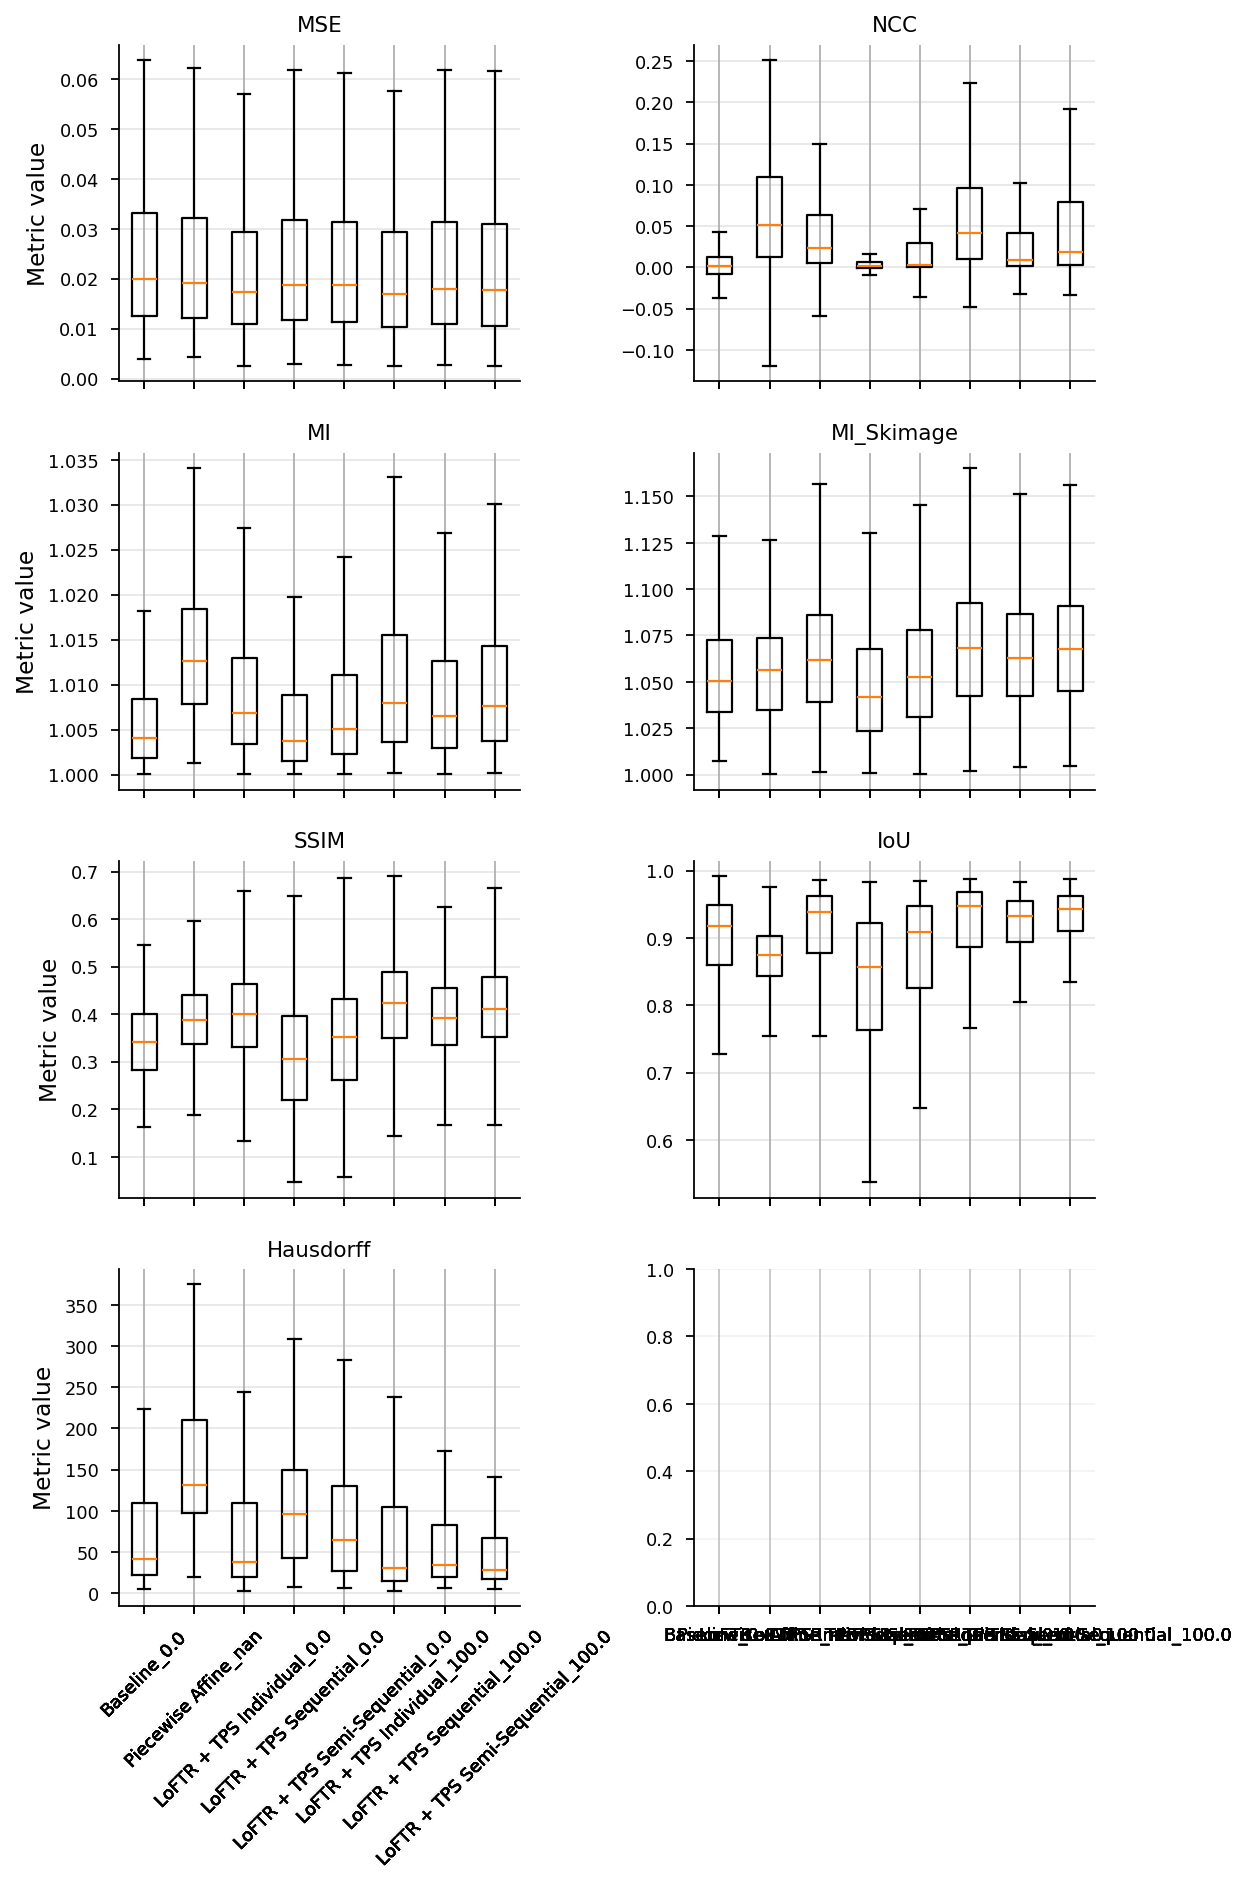

In [ ]:

metrics_unique = df_long["metric"].unique()

n_cols = 2
n_metrics = len(metrics)
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharex=True,
    sharey=False,
    # dpi=300
)

if len(metrics_unique) == 1:
    axes = [axes]

for row in range(n_rows):
    axes[row, 0].set_ylabel("Metric value", fontsize=10.5)

# for col in range(n_cols):
#     axes[n_rows-1, col].set_xlabel("Length of Series", fontsize=10.5)

axes = axes.flatten()


for ax, metric in zip(axes, metrics_unique):
    sub = df_long[df_long["metric"] == metric].copy()

    # force numeric once (important safety)
    sub["value"] = pd.to_numeric(sub["value"], errors="coerce")
    sub = sub.dropna(subset=["value"])

    groups = sub["group"].unique()

    data = []
    labels = []

    for g in groups:
        vals = sub.loc[sub["group"] == g, "value"].to_numpy()

        # critical: must be non-empty AND numeric
        if vals.size > 0:
            data.append(vals)
            labels.append(g)

    if len(data) == 0:
        print(f"Skipping {metric}: no valid data after filtering")
        continue

    ax.boxplot(data, tick_labels=labels, showfliers=False)

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experiments

In [4]:
df_no_consistency = pd.read_csv("results/seq_registration_no_consistency.csv")
df_min_dist_filter = pd.read_csv("results/seq_registration_min_dist_filter.csv")
df_cluster_filter = pd.read_csv("results/seq_registration_cluster_filter.csv")
df_grid_filter = pd.read_csv("results/seq_registration_grid_filter.csv")
df_with_markers = pd.read_csv("results/seq_registration_with_markers.csv")
df_full_leaf = pd.read_csv("results/seq_registration_full_leaf.csv")
df_unrotated_roi = pd.read_csv("results/seq_registration_unrotated_roi.csv")
df_unrotated_roi_hom = pd.read_csv("results/seq_registration_unrotated_roi_hom.csv")

In [5]:
experiment_set = df_no_consistency.leaf_uid.unique()
print(f"Number of Leaves tested: {len(experiment_set)}")

Number of Leaves tested: 38


In [246]:
df = pd.concat([df_no_consistency, df_min_dist_filter, df_cluster_filter, df_grid_filter, df_with_markers, df_full_leaf, df_unrotated_roi, df_unrotated_roi_hom, df_s100[df_s100.leaf_uid.isin(experiment_set)]], ignore_index=True)
df.sample(5)

,leaf_uid,registration_method,leaf_scale,pre_rotated,markers,warp_consistency,filtering_strategy,smoothing,fixed_image,moving_image,MSE,MAPE,NCC,MI,MI_Skimage,SSIM,IoU,Hausdorff
8185,ESWW0070075_2,LoFTR + TPS Sequential,roi,False,False,True,confidence,100,0,2,0.007260,73.977165,0.038163,1.010658,1.164049,0.742238,0.801841,351.124603
10055,ESWW0070180_1,LoFTR + TPS Sequential,roi,False,False,True,confidence,100,0,4,0.006072,73.315216,0.013311,1.005502,1.210869,0.739610,0.942337,15.000000
188,ESWW0070173_5,LoFTR + TPS Semi-Sequential,roi,True,False,False,confidence,100,0,12,0.034377,253.725525,0.055411,1.008894,1.082051,0.419269,0.943689,18.000000
5988,ESWW0090055_3,LoFTR + TPS Sequential,roi,True,True,True,confidence,100,0,9,0.059640,196.963043,0.005825,1.001475,1.034267,0.286498,0.837695,162.000000
7867,ESWW0090064_5,LoFTR + TPS Individual,roi,False,False,True,confidence,100,0,8,0.085418,201.419205,-0.005959,1.000513,1.028968,0.583442,0.203564,1203.361084


### Inspections

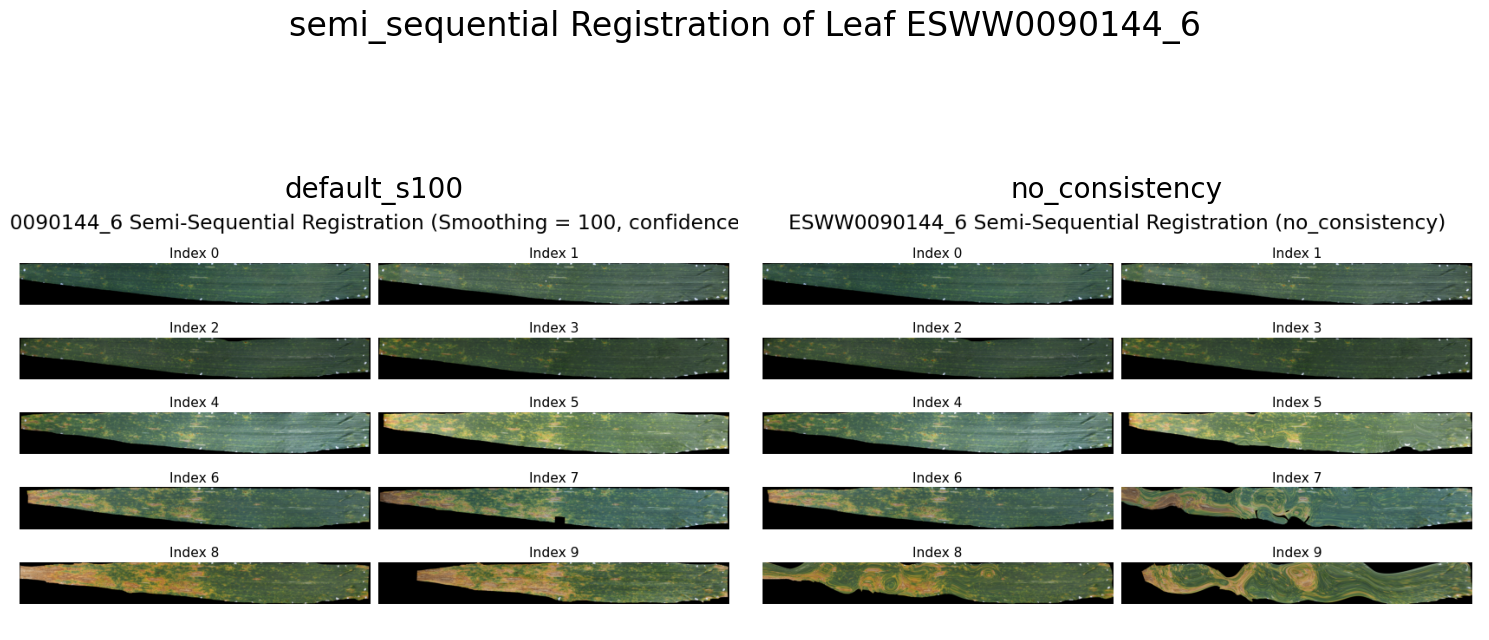

KeyboardInterrupt: 

In [7]:


method1 = method2 ='semi_sequential'
# method2 = 'sequential'
# method2 = 'individual'
config1 = 'default_s100'
# config1 = 'unrotated_roi'
config2 = 'no_consistency'
pause = 3
for uid in experiment_set:
    clear_output(wait=True) 
    fig = fetch_seq_res(uid, method1, method2, config1, config2)

    display(fig)
    plt.close(fig)

    time.sleep(pause)
    # plt.close()

In [9]:

method1 = method2 ='semi_sequential'
# method2 = 'sequential'
# method2 = 'individual'
config1 = 'default_s100'
config2 = 'no_consistency'
data = experiment_set

results = {}

i = 0

plot_out = widgets.Output()
ui_out = widgets.Output()

display(plot_out, ui_out)

def show():
    global i

    if i >= len(data):
        with ui_out:
            clear_output(wait=True)
            print("Done!")
            print(results)
        return

    uid = data[i]

    # replace old figure
    with plot_out:
        clear_output(wait=True)

        fig = fetch_seq_res(uid, method1, method2, config1, config2)

        # fig.show()
        display(fig)
        plt.close(fig)

    # replace old buttons
    with ui_out:
        clear_output(wait=True)

        btn_good = widgets.Button(description="Good")
        btn_mid = widgets.Button(description="Mid")
        btn_bad = widgets.Button(description="Bad")
        btn_nan = widgets.Button(description="NaN")

        display(widgets.HBox([btn_good, btn_mid, btn_bad, btn_nan]))

    def classify(label):
        global i

        results.update({uid: label})

        i += 1
        show()

    btn_good.on_click(lambda b: classify("Good"))
    btn_mid.on_click(lambda b: classify("Mid"))
    btn_bad.on_click(lambda b: classify("Bad"))
    btn_nan.on_click(lambda b: classify("NaN"))

show()

Output()

Output()

In [241]:
full_leaf_quality = pd.DataFrame({"method": method, "uid": results.keys(), "full_leaf_quality": results.values()})
full_leaf_quality.head()


,method,uid,full_leaf_quality
0,LoFTR + TPS Semi-Sequential,ESWW0090151_6,Mid
1,LoFTR + TPS Semi-Sequential,ESWW0070063_2,Mid
2,LoFTR + TPS Semi-Sequential,ESWW0090106_2,Mid
3,LoFTR + TPS Semi-Sequential,ESWW0090064_5,Bad
4,LoFTR + TPS Semi-Sequential,ESWW0070173_5,Bad


### Averaging over leaves

In [13]:
dfs = {'no_consistency': df_no_consistency, 
    'min_dist_filter': df_min_dist_filter, 
    'cluster_filter': df_cluster_filter, 
    'grid_filter': df_grid_filter, 
    'with_markers': df_with_markers, 
    'full_leaf': df_full_leaf, 
    'unrotated_roi': df_unrotated_roi, 
    'unrotated_roi_hom': df_unrotated_roi_hom, 
    'default_s100': df_s100[df_s100.leaf_uid.isin(experiment_set)]
}

# metrics = ["MSE", "NCC", "MI", "MI_Skimage", "SSIM", "IoU", "Hausdorff"]
metrics = ["MSE", "NCC", "MI", "SSIM", "IoU", "Hausdorff"]
group_cols = ['registration_method', 'fixed_image', 'moving_image']

In [ ]:
# average over leaf series for each index pair
df_agg = df_full.groupby(group_cols, dropna=False)[metrics].agg(["mean", "std"]).reset_index()
df_agg.columns = [ "_".join(col).rstrip("_") for col in df_agg.columns ]
df_agg.sample(5).sort_values(by=(group_cols))

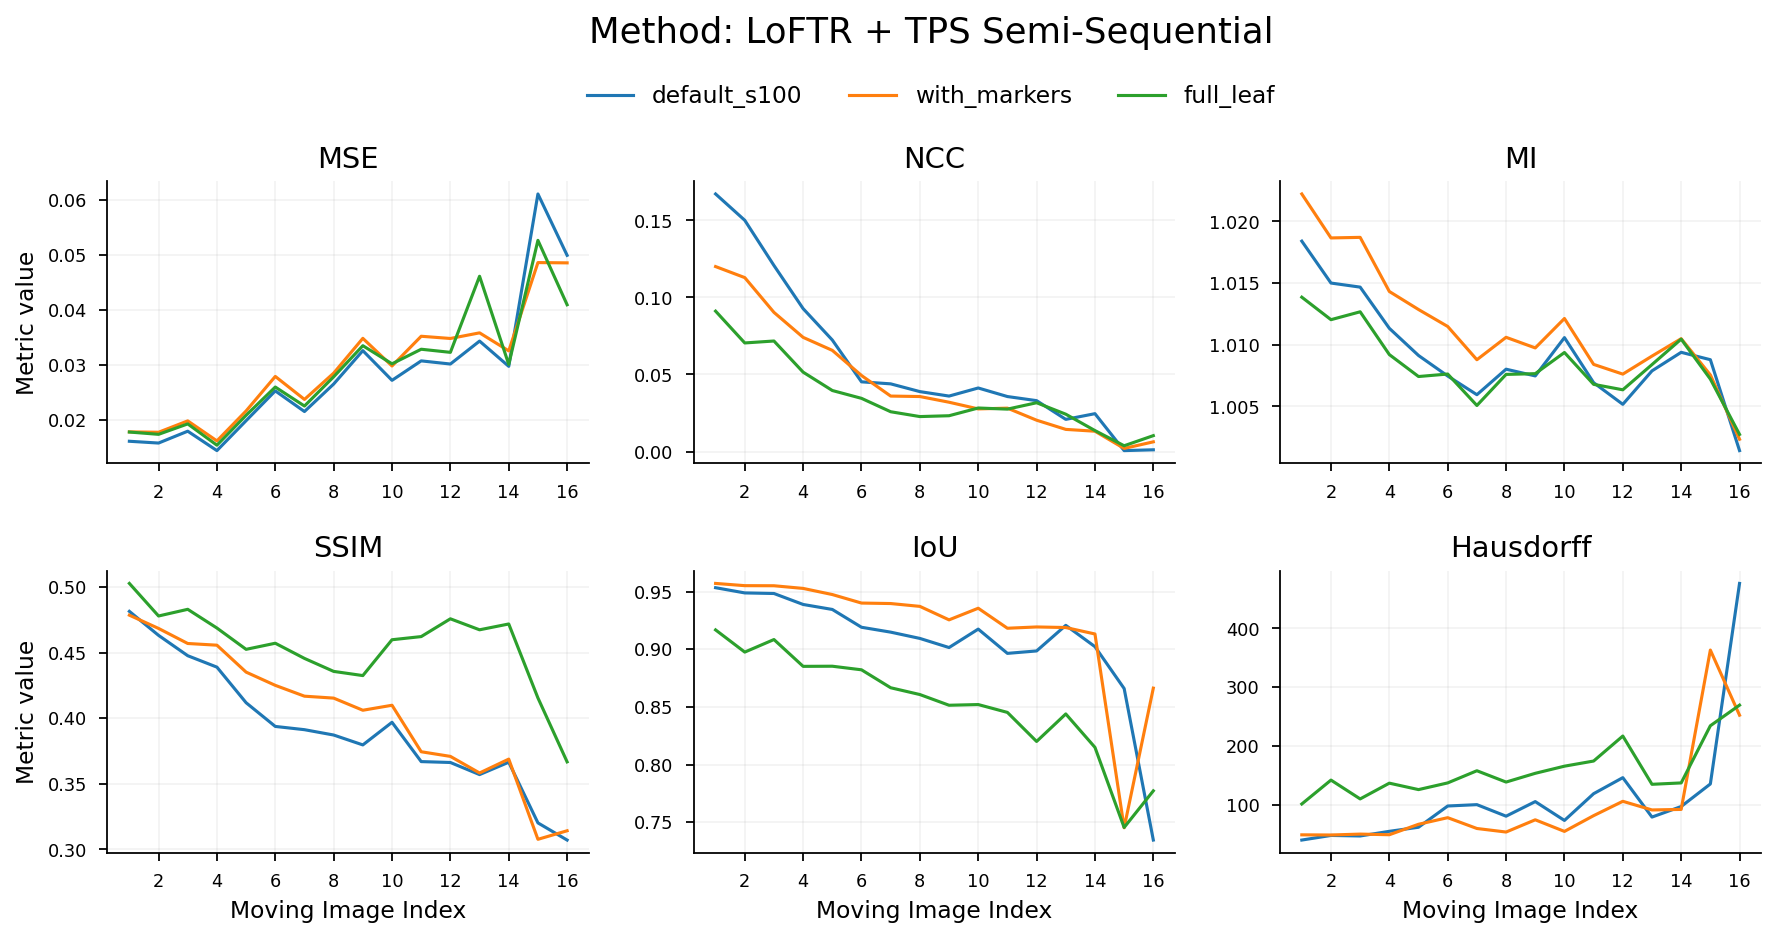

In [13]:
# configs = ['default_s100', 'min_dist_filter', 'cluster_filter', 'grid_filter']
configs = ['default_s100', 'with_markers', 'full_leaf']
# configs = ['default_s100', 'no_consistency']
# configs = ['default_s100', 'unrotated_roi', 'unrotated_roi_hom']

method = 'LoFTR + TPS Semi-Sequential'
n_metrics = len(metrics)

n_cols = 3
n_rows = math.ceil(n_metrics / n_cols)

# plt.style.use(['science', 'no-latex'])
plt.style.use('seaborn-v0_8-paper')

plt.rcParams.update({
    "figure.dpi": 160,
    "font.size": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    # "lines.linewidth": 2,
})


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharex=True,
    sharey=False,
    # dpi=300
)

for row in range(n_rows):
    axes[row, 0].set_ylabel("Metric value", fontsize=10.5)

for col in range(n_cols):
    axes[n_rows-1, col].set_xlabel("Moving Image Index", fontsize=10.5)

axes = axes.flatten()

for cfg in configs:
    df_cfg = dfs[cfg]
    df_cfg = df_cfg[df_cfg['registration_method'] == method]
    df_agg = df_cfg.groupby('moving_image', dropna=False)[metrics].agg(["mean", "std"]).reset_index()
    df_agg.columns = [ "_".join(col).rstrip("_") for col in df_agg.columns ]
    df_agg.sort_values("moving_image")
    for ax, metric in zip(axes, metrics):
        # for method in methods:
            # if method == "Piecewise Affine" or method == "Baseline":
            #     df_plot = df_agg[
            #         (df_agg["fixed_image"] == 0) &
            #         (df_agg["registration_method"] == method) &
            #         (df_agg["moving_image"] != 0)
            #     ].sort_values("moving_image")
            # else:
            #     df_plot = df_agg[
            #         (df_agg["smoothing"] == smoothing) &
            #         (df_agg["fixed_image"] == 0) &
            #         (df_agg["registration_method"] == method) &
            #         (df_agg["moving_image"] != 0)
            #     ].sort_values("moving_image")

            # if df_plot.empty:
            #     continue

        x = df_agg["moving_image"]
        mean = df_agg[f"{metric}_mean"]
        std = df_agg[f"{metric}_std"]

        ax.plot(x, mean, label=cfg)
        # ax.fill_between(x, mean - std, mean + std, alpha=0.2, label="_nolegend_")
        # if metric == "Hausdorff":
        #     ax.set_yscale('log')

        ax.set_title(metric, fontsize=13)
        ax.grid(True)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.tick_params(labelbottom=True)
        # ax.set_xlabel("Moving Image Index")

# hide unused subplots
for ax in axes[len(metrics):]:
    ax.set_visible(False)
    

# shared y-label
# axes[0].set_ylabel("Metric value")

# put legend far right outside
fig.legend(
    configs,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    fontsize=10.5,
    ncol=len(configs),
    frameon=False,
)

fig.suptitle(f"Method: {method}", fontsize=16)

# tighten layout to remove empty space
fig.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()


### Full Average

In [14]:
configs = ['default_s100', 'no_consistency', 'min_dist_filter', 'cluster_filter', 'grid_filter', 'with_markers', 'full_leaf', 'unrotated_roi', 'unrotated_roi_hom']

# smoothness = 100
# metrics = ["MSE", "NCC", "MI", "MI_Skimage", "SSIM", "IoU", "Hausdorff"]
metrics = ["MSE", "NCC", "MI", "SSIM", "IoU", "Hausdorff"]
group_cols = ['registration_method', 'smoothing']
# methods = df_full["registration_method"].unique()
# methods
method = 'LoFTR + TPS Semi-Sequential'

rows = {}
for cfg in configs:
    df_cfg = dfs[cfg]
    df_cfg = df_cfg[df_cfg['registration_method'] == method]

    df_avg = df_cfg[metrics].agg(["mean", "std"])#.reset_index()
    # print(df_avg.head())

    row = {}

    for metric in df_avg.columns:
        row[f"{metric}_mean"] = df_avg.loc["mean", metric]
        row[f"{metric}_std"] = df_avg.loc["std", metric]

    rows[cfg] = row
    # df_avg.columns = [ "_".join(col).rstrip("_") for col in df_avg.columns ]
# df_avg.head()
experiment_avg = pd.DataFrame.from_dict(rows, orient="index")
experiment_avg

,MSE_mean,MSE_std,NCC_mean,NCC_std,MI_mean,MI_std,SSIM_mean,SSIM_std,IoU_mean,IoU_std,Hausdorff_mean,Hausdorff_std
default_s100,0.023002,0.017647,0.076575,0.111773,1.010478,0.009521,0.413084,0.087172,0.925140,0.058516,77.223735,137.760011
no_consistency,0.022797,0.017976,0.098026,0.122664,1.011236,0.009958,0.419913,0.094556,0.934138,0.049141,56.307449,86.190925
min_dist_filter,0.022756,0.017743,0.106721,0.159086,1.011672,0.010407,0.428548,0.097814,0.931851,0.051557,65.419780,112.305305
cluster_filter,0.022781,0.017734,0.104688,0.155481,1.011573,0.010321,0.427036,0.096846,0.931891,0.051439,64.950499,112.454989
grid_filter,0.022763,0.017751,0.106582,0.157856,1.011646,0.010380,0.429031,0.097097,0.931617,0.051707,65.127143,111.195524
with_markers,0.025025,0.017717,0.060587,0.091496,1.013451,0.010553,0.428317,0.092561,0.939182,0.061927,66.904867,134.674249
full_leaf,0.025004,0.019781,0.043326,0.079774,1.009049,0.008762,0.461798,0.122538,0.872056,0.072881,142.837418,106.987477
unrotated_roi,0.022545,0.017571,0.070739,0.102642,1.010807,0.009972,0.645036,0.087968,0.907519,0.097828,66.228712,104.615802
unrotated_roi_hom,0.022867,0.018253,0.061471,0.094838,1.010426,0.010143,0.634443,0.093239,0.897201,0.126911,70.031309,117.638094


In [15]:
# for exporting to latex
df_latex = experiment_avg.copy()


precision = {
    # 'MSE': {"mean": 4, "std": 3}, 
    # 'NCC': {"mean": 4, "std": 2}, 
    # 'MI': {"mean": 4, "std": 4}, 
    # 'MI_Skimage': {"mean": 4, "std": 3}, 
    # 'SSIM': {"mean": 3, "std": 3}, 
    # 'IoU': {"mean": 3, "std": 3}, 
    'Hausdorff': {"mean": 2, "std": 1},
}

default_mean = 4
default_std = 3

for m in metrics:
    mean_digits = precision.get(m, {}).get("mean", default_mean)
    std_digits = precision.get(m, {}).get("std", default_std)

    df_latex[f"{m}"] = (
        df_latex[f"{m}_mean"].map(lambda x: f"{x:.{mean_digits}f}") #+
        # " $\\pm$ " +
        # df_latex[f"{m}_std"].map(lambda x: f"{x:.{std_digits}f}")
    )

df_latex[metrics]
print(df_latex[metrics].to_latex(index=True))

\begin{tabular}{lllllll}
\toprule
 & MSE & NCC & MI & SSIM & IoU & Hausdorff \\
\midrule
default_s100 & 0.0230 & 0.0766 & 1.0105 & 0.4131 & 0.9251 & 77.22 \\
no_consistency & 0.0228 & 0.0980 & 1.0112 & 0.4199 & 0.9341 & 56.31 \\
min_dist_filter & 0.0228 & 0.1067 & 1.0117 & 0.4285 & 0.9319 & 65.42 \\
cluster_filter & 0.0228 & 0.1047 & 1.0116 & 0.4270 & 0.9319 & 64.95 \\
grid_filter & 0.0228 & 0.1066 & 1.0116 & 0.4290 & 0.9316 & 65.13 \\
with_markers & 0.0250 & 0.0606 & 1.0135 & 0.4283 & 0.9392 & 66.90 \\
full_leaf & 0.0250 & 0.0433 & 1.0090 & 0.4618 & 0.8721 & 142.84 \\
unrotated_roi & 0.0225 & 0.0707 & 1.0108 & 0.6450 & 0.9075 & 66.23 \\
unrotated_roi_hom & 0.0229 & 0.0615 & 1.0104 & 0.6344 & 0.8972 & 70.03 \\
\bottomrule
\end{tabular}

